# 🔄 Notebook 05 — Migration Analysis & Competitive Intelligence
## SentimentCompass: Understanding User Satisfaction, Topic Trends, and Migration Signals

---

**Project:** SentimentCompass  
**Input:** `data/processed/reviews_topics.parquet`  
**Purpose:** Discover competitive mention patterns, identify users switching between AI platforms, extract migration reasons, and build a directed migration network.

### 🎯 Three-tier detection pipeline

| Tier | What it finds | Method |
|------|--------------|--------|
| **Mention detection** | Any competitor name in a review | Regex word-boundary matching, 6+ aliases per platform |
| **Migration detection** | Switching language near a competitor mention | TO/FROM phrase matching within ±120-char context window |
| **Reason extraction** | Why the user switched | Keyword scoring across 10 reason categories |

> **Methodology note:** This is a rule-based pipeline — robust, interpretable, and reproducible without any ML training. False positives are minimised by requiring both a competitor alias AND a migration phrase within the same context window.

### 📋 Table of Contents

| Section | Description | New columns |
|---------|-------------|------------|
| §1–2 | Setup & load data | — |
| §3 | Platform mention detection | `mentioned_platforms`, `mention_count`, `mentions_competitor` |
| §4 | Migration intent detection | `migration_flag`, `migration_source`, `migration_destination`, `migration_reason_text` |
| §5 | Reason categorisation | `migration_reason_category` |
| §6 | Competitive intelligence scorecards | — |
| §7 | Migration network analysis (NetworkX) | — |
| §8 | Migration sentiment analysis | — |
| §9 | 7 visualisations | — |
| §10–11 | Export + executive summary | — |

---
## ⚙️ Section 1 — Setup & Configuration

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os, re, time, warnings

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Network analysis ──────────────────────────────────────────────────────────
import networkx as nx

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ── Display ───────────────────────────────────────────────────────────────────
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "grid.color"        : "#E8E8E8",
    "grid.linewidth"    : 0.8,
})

# ── Platform palette ──────────────────────────────────────────────────────────
APP_COLORS = {
    "ChatGPT"           : "#1D9E75",
    "Google_Gemini"     : "#378ADD",
    "Claude"            : "#534AB7",
    "Microsoft_Copilot" : "#BA7517",
    "Perplexity"        : "#D85A30",
}
APP_ORDER  = ["ChatGPT", "Google_Gemini", "Claude", "Microsoft_Copilot", "Perplexity"]
APP_LABELS = {
    "ChatGPT"           : "ChatGPT",
    "Google_Gemini"     : "Gemini",
    "Claude"            : "Claude",
    "Microsoft_Copilot" : "MS Copilot",
    "Perplexity"        : "Perplexity",
}
PALETTE = [APP_COLORS[a] for a in APP_ORDER]

# ── Platform aliases (regex patterns, lowercase) ──────────────────────────────
PLATFORM_ALIASES = {
    "ChatGPT": [
        "chatgpt", "chat gpt", "gpt-4o", "gpt-4", "gpt4o", "gpt4",
        "gpt 4", "gpt-3", "gpt3", "gpt 3", "openai", "chat.openai",
        "gpt-o", "o1 model", "o3 model",
    ],
    "Google_Gemini": [
        "gemini", "google gemini", "bard", "google bard",
        "gemini pro", "gemini ultra", "gemini nano", "google ai",
    ],
    "Claude": [
        "claude", "claude ai", "claude.ai", "claude 2", "claude 3",
        "claude opus", "claude sonnet", "claude haiku", "anthropic",
    ],
    "Microsoft_Copilot": [
        "copilot", "microsoft copilot", "bing ai", "bing chat",
        "ms copilot", "bing copilot", "windows copilot", "github copilot",
    ],
    "Perplexity": [
        "perplexity", "perplexity ai", "perplexity.ai",
    ],
}

# ── Migration signal phrases ───────────────────────────────────────────────────
# TO phrases → user is LEAVING the reviewed platform FOR the mentioned one
TO_PHRASES = [
    "switched to", "switching to", "switch to",
    "moved to", "moving to", "migrated to",
    "left for", "going to use", "now using",
    "now use", "started using", "replaced with",
    "using instead", "trying instead", "going with",
    "will use", "will try", "plan to use",
]

# FROM phrases → user CAME FROM the mentioned platform TO the reviewed one
FROM_PHRASES = [
    "switched from", "switching from",
    "moved from", "migrated from",
    "coming from", "came from",
    "previously used", "used to use",
    "was using", "used to be on",
    "left", "abandoned", "quit",
]

# ── Migration reason keyword dictionary (10 categories) ───────────────────────
REASON_KEYWORDS = {
    "Pricing"           : ["price", "cost", "expensive", "cheap", "free", "subscription",
                            "pay", "money", "afford", "worth", "value", "paid", "billing",
                            "cancel", "refund", "charge"],
    "Accuracy"          : ["accurate", "wrong", "correct", "mistake", "hallucinate",
                            "reliable", "false", "incorrect", "factual", "truth", "error",
                            "outdated", "misinformation"],
    "Coding Quality"    : ["code", "coding", "programming", "debug", "developer",
                            "python", "javascript", "sql", "function", "script",
                            "software", "algorithm", "compile"],
    "Writing Quality"   : ["write", "writing", "essay", "content", "creative",
                            "story", "blog", "email", "draft", "grammar", "copywriting",
                            "article", "text", "prose"],
    "Speed"             : ["fast", "slow", "speed", "quick", "lag", "response",
                            "delay", "instant", "latency", "wait", "loading", "performance"],
    "User Experience"   : ["easy", "interface", "ux", "ui", "design", "simple",
                            "intuitive", "navigation", "app", "clean", "usability",
                            "feature", "button", "mobile"],
    "Reliability"       : ["reliable", "stable", "crash", "bug", "error", "down",
                            "offline", "outage", "glitch", "broken", "unavailable",
                            "service", "uptime"],
    "Privacy"           : ["privacy", "data", "secure", "safe", "gdpr",
                            "track", "collect", "personal", "history", "delete",
                            "anonymous", "confidential"],
    "Search Quality"    : ["search", "web", "browse", "internet", "real-time",
                            "current", "news", "latest", "online", "source", "link",
                            "up to date", "updated"],
    "General"           : ["better", "worse", "prefer", "like", "love", "hate",
                            "overall", "good", "bad", "best", "worst", "recommend",
                            "suggest", "opinion"],
}

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = "../data/processed/"
FIGURES_DIR   = "../outputs/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

INPUT_PATH  = os.path.join(PROCESSED_DIR, "reviews_topics.parquet")
OUT_PARQ    = os.path.join(PROCESSED_DIR, "reviews_migration.parquet")
OUT_CSV     = os.path.join(PROCESSED_DIR, "reviews_migration.csv")
OUT_MIGSUM  = os.path.join(PROCESSED_DIR, "migration_summary.csv")
OUT_CI      = os.path.join(PROCESSED_DIR, "platform_competitive_intelligence.csv")

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  📁  Saved → {path}")

print("✅  Setup complete.")
print(f"    NetworkX {nx.__version__}")

✅  Setup complete.
    NetworkX 3.6.1


---
## 📂 Section 2 — Load Dataset

In [2]:
df = pd.read_parquet(INPUT_PATH)

print("=" * 60)
print("  DATASET LOADED")
print("=" * 60)
print(f"  Rows       : {df.shape[0]:>10,}")
print(f"  Columns    : {df.shape[1]:>10}")
print(f"  Memory     : {df.memory_usage(deep=True).sum()/1e6:>9.2f} MB")
print("=" * 60)

# Verify key columns
required = ["review_text_clean", "App", "Star_Rating",
            "vader_compound", "vader_label",
            "is_positive_review", "is_negative_review",
            "lda_topic_label"]
missing  = [c for c in required if c not in df.columns]
if missing:
    print(f"\n⚠   Missing columns — ensure NB02, NB03, NB04 have run: {missing}")
else:
    print("\n✅  All required columns present.")

print()
print("Platform distribution:")
for app in APP_ORDER:
    n = (df["App"] == app).sum()
    print(f"  {APP_LABELS[app]:<14} : {n:,}")

  DATASET LOADED
  Rows       :     50,000
  Columns    :         49
  Memory     :     43.18 MB

✅  All required columns present.

Platform distribution:
  ChatGPT        : 10,000
  Gemini         : 10,000
  Claude         : 10,000
  MS Copilot     : 10,000
  Perplexity     : 10,000


---
## 🔎 Section 3 — Platform Mention Detection

We scan every review for mentions of competing AI platforms using regex word-boundary matching. Reviews of Platform A are searched for mentions of Platforms B, C, D, and E — but NOT Platform A itself (self-references are excluded to avoid noise).

**Aliases covered per platform:**

| Platform | Key aliases |
|----------|-------------|
| ChatGPT | chatgpt, gpt-4, gpt4, gpt-3, openai |
| Gemini | gemini, bard, google gemini, google bard |
| Claude | claude, anthropic, claude 2/3, claude opus/sonnet |
| MS Copilot | copilot, bing ai, bing chat, ms copilot |
| Perplexity | perplexity, perplexity ai |

In [3]:
# Pre-compile regex patterns for each platform (word-boundary matching)
COMPILED_PATTERNS = {}
for platform, aliases in PLATFORM_ALIASES.items():
    # Sort by length descending to match longer aliases first
    sorted_aliases = sorted(aliases, key=len, reverse=True)
    # Escape and join as alternation
    pattern_str = "|".join(r"\b" + re.escape(a) + r"\b" for a in sorted_aliases)
    COMPILED_PATTERNS[platform] = re.compile(pattern_str, re.IGNORECASE)


def find_competitor_mentions(text, reviewed_app):
    if not isinstance(text, str) or not text.strip():
        return []
    mentioned = []
    for platform, pattern in COMPILED_PATTERNS.items():
        if platform == reviewed_app:
            continue  # Skip self-mentions
        if pattern.search(text):
            mentioned.append(platform)
    return mentioned


# ── Test the function ─────────────────────────────────────────────────────────
test_cases = [
    ("ChatGPT",    "I switched from Gemini because Claude handles long texts better"),
    ("Claude",     "ChatGPT is faster but Perplexity has better search"),
    ("Perplexity", "I use Copilot at work and OpenAI at home"),
    ("Google_Gemini", "This is way better than GPT-4, no comparison"),
]
print("find_competitor_mentions() test cases:")
print("-" * 60)
for app, text in test_cases:
    result = find_competitor_mentions(text, app)
    print(f"  App: {APP_LABELS[app]:<14}  Found: {[APP_LABELS[r] for r in result]}")
    print(f"  Text: \"{text[:70]}\"")
    print()

find_competitor_mentions() test cases:
------------------------------------------------------------
  App: ChatGPT         Found: ['Gemini', 'Claude']
  Text: "I switched from Gemini because Claude handles long texts better"

  App: Claude          Found: ['ChatGPT', 'Perplexity']
  Text: "ChatGPT is faster but Perplexity has better search"

  App: Perplexity      Found: ['ChatGPT', 'MS Copilot']
  Text: "I use Copilot at work and OpenAI at home"

  App: Gemini          Found: ['ChatGPT']
  Text: "This is way better than GPT-4, no comparison"



In [4]:
print(f"Running mention detection on {len(df):,} reviews...")
print("(Expected: 2–4 minutes)")
_t0 = time.time()

_results = []
for _, row in df.iterrows():
    mentions = find_competitor_mentions(row["review_text_clean"], row["App"])
    _results.append(mentions)

# ── Append columns ─────────────────────────────────────────────────────────────
df["mentioned_platforms"] = ["|".join(m) if m else "" for m in _results]
df["mention_count"]       = [len(m) for m in _results]
df["mentions_competitor"] = [len(m) > 0 for m in _results]

print(f"✅  Done in {time.time()-_t0:.1f}s")
print()
print("Mention detection results:")
n_with_mentions = df["mentions_competitor"].sum()
print(f"  Reviews mentioning ≥1 competitor : {n_with_mentions:,}  "
      f"({n_with_mentions/len(df)*100:.1f}%)")
print(f"  Reviews mentioning  0 competitors : {(~df['mentions_competitor']).sum():,}")
print(f"  Reviews mentioning  2+ competitors: "
      f"{(df['mention_count'] >= 2).sum():,}")

Running mention detection on 50,000 reviews...
(Expected: 2–4 minutes)
✅  Done in 4.4s

Mention detection results:
  Reviews mentioning ≥1 competitor : 4,368  (8.7%)
  Reviews mentioning  0 competitors : 45,632
  Reviews mentioning  2+ competitors: 648


In [5]:
# ── Per-platform mention summary ───────────────────────────────────────────────
print("Competitor mentions in each platform's reviews:")
print("=" * 70)
for app in APP_ORDER:
    sub       = df[df["App"] == app]
    n_mention = sub["mentions_competitor"].sum()
    rate      = n_mention / len(sub) * 100
    # Which competitors are most mentioned?
    all_comps = []
    for m in sub["mentioned_platforms"].dropna():
        if m:
            all_comps.extend(m.split("|"))
    if all_comps:
        comp_counts = pd.Series(all_comps).value_counts()
        top_comp    = APP_LABELS[comp_counts.idxmax()]
        top_n       = comp_counts.max()
    else:
        top_comp, top_n = "None", 0
    print(f"  {APP_LABELS[app]:<14}  mentions={n_mention:>5,}  "
          f"rate={rate:.1f}%  most_mentioned={top_comp} ({top_n})")

print()

# ── How often is each platform MENTIONED in other platforms' reviews? ──────────
print("How often is each platform MENTIONED in competitors' reviews?")
print("-" * 55)
incoming_mentions = {}
for platform in APP_ORDER:
    # Count mentions of this platform in OTHER platforms' reviews
    label = APP_LABELS[platform]
    count = 0
    for _, row in df[df["App"] != platform].iterrows():
        if platform in (row["mentioned_platforms"] or "").split("|"):
            count += 1
    incoming_mentions[platform] = count
    print(f"  {label:<14} is mentioned {count:>5,} times in competitors' reviews")

Competitor mentions in each platform's reviews:
  ChatGPT         mentions=  215  rate=2.1%  most_mentioned=Gemini (139)
  Gemini          mentions=  489  rate=4.9%  most_mentioned=ChatGPT (447)
  Claude          mentions=1,515  rate=15.2%  most_mentioned=ChatGPT (1326)
  MS Copilot      mentions=  774  rate=7.7%  most_mentioned=ChatGPT (564)
  Perplexity      mentions=1,375  rate=13.8%  most_mentioned=ChatGPT (1185)

How often is each platform MENTIONED in competitors' reviews?
-------------------------------------------------------
  ChatGPT        is mentioned 3,522 times in competitors' reviews
  Gemini         is mentioned 1,134 times in competitors' reviews
  Claude         is mentioned   183 times in competitors' reviews
  MS Copilot     is mentioned   110 times in competitors' reviews
  Perplexity     is mentioned   133 times in competitors' reviews


---
## 🚀 Section 4 — Migration Intent Detection

A **migration event** requires two conditions to be met simultaneously within the same ±120-character context window:
1. A competitor platform alias is present
2. A switching-intent phrase is present

**Direction logic:**
- **TO phrase** near competitor B in a review of platform A → user is **leaving A for B** (source=A, dest=B)
- **FROM phrase** near competitor B in a review of platform A → user **came from B to A** (source=B, dest=A)

This approach achieves high precision by requiring both elements to co-occur, filtering out casual comparisons like "Gemini is great" without any migration language.

In [6]:
CONTEXT_WINDOW = 120   # characters around each competitor alias

def detect_migration(text, reviewed_app, competitor_list):
    if not isinstance(text, str) or not text.strip() or not competitor_list:
        return False, None, None, None, None

    text_lower = text.lower()

    for comp in competitor_list:
        for alias in sorted(PLATFORM_ALIASES[comp], key=len, reverse=True):
            pattern = re.compile(r"\b" + re.escape(alias) + r"\b", re.IGNORECASE)
            for match in pattern.finditer(text_lower):
                pos     = match.start()
                start_c = max(0, pos - CONTEXT_WINDOW)
                end_c   = min(len(text_lower), pos + CONTEXT_WINDOW)
                context = text_lower[start_c:end_c]

                # Check TO phrases first (stronger signal)
                for phrase in TO_PHRASES:
                    if phrase in context:
                        snippet = text[start_c:end_c].strip()
                        return True, reviewed_app, comp, phrase, snippet[:150]

                # Check FROM phrases
                for phrase in FROM_PHRASES:
                    if phrase in context:
                        snippet = text[start_c:end_c].strip()
                        return True, comp, reviewed_app, phrase, snippet[:150]

    return False, None, None, None, None


# ── Unit test ─────────────────────────────────────────────────────────────────
migration_tests = [
    ("ChatGPT", "I switched to Claude last month and never looked back",   ["Claude"]),
    ("Claude",  "Moved from ChatGPT to Claude because pricing is better", ["ChatGPT"]),
    ("Perplexity","ChatGPT is definitely better at creative writing",      ["ChatGPT"]),
    ("Google_Gemini","I was using Copilot but Gemini is much more reliable",["Microsoft_Copilot"]),
]
print("detect_migration() test cases:")
print("-" * 65)
for app, text, comps in migration_tests:
    flag, src, dst, phrase, snippet = detect_migration(text, app, comps)
    if flag:
        print(f"  ✅  MIGRATION  [{APP_LABELS.get(src,'?')} → {APP_LABELS.get(dst,'?')}]  phrase='{phrase}'")
    else:
        print(f"  ○   NO MIGRATION (comparison only)")
    print(f"     Text: \"{text[:80]}\"")
    print()

detect_migration() test cases:
-----------------------------------------------------------------
  ✅  MIGRATION  [ChatGPT → Claude]  phrase='switched to'
     Text: "I switched to Claude last month and never looked back"

  ✅  MIGRATION  [ChatGPT → Claude]  phrase='moved from'
     Text: "Moved from ChatGPT to Claude because pricing is better"

  ○   NO MIGRATION (comparison only)
     Text: "ChatGPT is definitely better at creative writing"

  ✅  MIGRATION  [MS Copilot → Gemini]  phrase='was using'
     Text: "I was using Copilot but Gemini is much more reliable"



In [7]:
print(f"Running migration detection on {df['mentions_competitor'].sum():,} "
      f"competitor-mention reviews...")
print("(Expected: 1–3 minutes)")
_t0 = time.time()

# Initialise columns
df["migration_flag"]        = False
df["migration_source"]      = None
df["migration_destination"] = None
df["migration_phrase"]      = None
df["migration_reason_text"] = None

# Only process reviews that already mention a competitor (efficiency)
mention_mask = df["mentions_competitor"] == True

for idx in df[mention_mask].index:
    row       = df.loc[idx]
    comps     = [p for p in (row["mentioned_platforms"] or "").split("|") if p]
    flag, src, dst, phrase, snippet = detect_migration(
        row["review_text_clean"], row["App"], comps
    )
    if flag:
        df.at[idx, "migration_flag"]        = True
        df.at[idx, "migration_source"]      = src
        df.at[idx, "migration_destination"] = dst
        df.at[idx, "migration_phrase"]      = phrase
        df.at[idx, "migration_reason_text"] = snippet

n_mig = df["migration_flag"].sum()
print(f"✅  Migration detection done in {time.time()-_t0:.1f}s")
print(f"    Migration events detected : {n_mig:,}  "
      f"({n_mig/len(df)*100:.2f}% of all reviews)")
print(f"    Of competitor-mention reviews: "
      f"{n_mig/df['mentions_competitor'].sum()*100:.1f}%")

Running migration detection on 4,368 competitor-mention reviews...
(Expected: 1–3 minutes)
✅  Migration detection done in 1.8s
    Migration events detected : 202  (0.40% of all reviews)
    Of competitor-mention reviews: 4.6%


In [8]:
# ── Migration examples ────────────────────────────────────────────────────────
mig_df = df[df["migration_flag"] == True].copy()
mig_df["src_label"] = mig_df["migration_source"].map(
    lambda x: APP_LABELS.get(x, "Unknown") if x else "Unknown"
)
mig_df["dst_label"] = mig_df["migration_destination"].map(
    lambda x: APP_LABELS.get(x, "Unknown") if x else "Unknown"
)

print(f"Total migration events: {len(mig_df):,}")
print()
print("Migration direction summary (top 10):")
mig_flows = (mig_df.groupby(["src_label", "dst_label"])
               .size()
               .reset_index(name="count")
               .sort_values("count", ascending=False))
print(mig_flows.head(10).to_string(index=False))

print()
print("Sample migration review snippets:")
print("-" * 65)
for _, row in mig_df.sample(min(5, len(mig_df)), random_state=42).iterrows():
    print(f"  [{row['src_label']} → {row['dst_label']}]  "
          f"phrase='{row['migration_phrase']}'")
    print(f"  snippet: \"{row['migration_reason_text'][:120]}\"")
    print()

Total migration events: 202

Migration direction summary (top 10):
 src_label  dst_label  count
   ChatGPT     Claude     66
    Claude    ChatGPT     44
   ChatGPT     Gemini     16
Perplexity    ChatGPT     13
   ChatGPT Perplexity     11
Perplexity     Gemini      8
    Gemini MS Copilot      6
    Gemini     Claude      6
    Claude     Gemini      6
MS Copilot     Gemini      6

Sample migration review snippets:
-----------------------------------------------------------------
  [Claude → Gemini]  phrase='switched to'
  snippet: "I've been using Gemini for years. I just switched to claude for about 5 minutes and I immediately loved it. Claude will "

  [Gemini → MS Copilot]  phrase='quit'
  snippet: "ith the way it helps you write letters and also the way it can dictate for you quite accurately actually as I have used "

  [ChatGPT → Gemini]  phrase='switched from'
  snippet: "Switched from ChatGPT to Gemini and I love it! It perfectly understood and explained a Tamil meme I uploa

---
## 🏷️ Section 5 — Migration Reason Categorisation

Each migration event's context snippet is scored against 10 keyword dictionaries. The category with the highest keyword overlap wins. This converts unstructured text into actionable business categories without any ML training.

In [9]:
def categorize_reason(text, keyword_map=REASON_KEYWORDS):
    if not isinstance(text, str) or not text.strip():
        return "General"
    text_lower = text.lower()
    scores = {}
    for category, keywords in keyword_map.items():
        scores[category] = sum(1 for kw in keywords if kw in text_lower)
    best_cat   = max(scores, key=scores.get)
    best_score = scores[best_cat]
    # Fallback if no keyword matches
    return best_cat if best_score > 0 else "General"


# ── Apply to migration rows only ──────────────────────────────────────────────
df["migration_reason_category"] = None

mig_mask = df["migration_flag"] == True
df.loc[mig_mask, "migration_reason_category"] = (
    df.loc[mig_mask, "migration_reason_text"]
      .apply(categorize_reason)
)

# ── Frequency table ───────────────────────────────────────────────────────────
reason_counts = (df[mig_mask]["migration_reason_category"]
                 .value_counts()
                 .reset_index())
reason_counts.columns = ["Reason Category", "Count"]
reason_counts["Percentage"] = (reason_counts["Count"] /
                                reason_counts["Count"].sum() * 100).round(1)

print("Migration reason category distribution:")
print("-" * 48)
for _, row in reason_counts.iterrows():
    bar = "█" * int(row["Percentage"] / 2)
    print(f"  {row['Reason Category']:<22}  {row['Count']:>4}  "
          f"({row['Percentage']:.1f}%)  {bar}")

print()
top_reason = reason_counts.iloc[0]["Reason Category"]
print(f"Most common migration reason: {top_reason}")

Migration reason category distribution:
------------------------------------------------
  General                   87  (43.1%)  █████████████████████
  User Experience           44  (21.8%)  ██████████
  Pricing                   19  (9.4%)  ████
  Accuracy                  13  (6.4%)  ███
  Speed                     11  (5.4%)  ██
  Privacy                    8  (4.0%)  ██
  Coding Quality             8  (4.0%)  ██
  Writing Quality            6  (3.0%)  █
  Reliability                4  (2.0%)  █
  Search Quality             2  (1.0%)  

Most common migration reason: General


---
## 🏆 Section 6 — Competitive Intelligence Scorecards

A platform scorecard consolidates every competitive signal into a single structured row. This becomes the basis for the final report's "competitive landscape" section.

In [10]:
ci_rows = []

for app in APP_ORDER:
    sub      = df[df["App"] == app]
    sub_mig  = df[df["migration_flag"] == True]

    # Mention stats (this platform's own reviews)
    n_comp_mentions = sub["mentions_competitor"].sum()
    mention_rate    = n_comp_mentions / len(sub) * 100

    # Most mentioned competitor in this platform's reviews
    all_comps = []
    for m in sub["mentioned_platforms"].dropna():
        if m:
            all_comps.extend(m.split("|"))
    if all_comps:
        comp_ser  = pd.Series(all_comps).value_counts()
        top_comp  = APP_LABELS.get(comp_ser.idxmax(), comp_ser.idxmax())
        top_n     = int(comp_ser.max())
    else:
        top_comp, top_n = "None", 0

    # Migration gains (users arriving at this platform)
    gains = (sub_mig["migration_destination"] == app).sum()

    # Migration losses (users leaving this platform)
    losses = (sub_mig["migration_source"] == app).sum()

    # Net migration
    net = int(gains) - int(losses)

    # Top reason in migration events involving this platform
    mig_related = sub_mig[
        (sub_mig["migration_source"] == app) |
        (sub_mig["migration_destination"] == app)
    ]
    if len(mig_related) > 0 and "migration_reason_category" in mig_related.columns:
        top_reason = (mig_related["migration_reason_category"]
                      .dropna()
                      .value_counts()
                      .idxmax() if mig_related["migration_reason_category"].notna().any()
                      else "N/A")
    else:
        top_reason = "N/A"

    # Sentiment of migration mentions
    mig_sent = (mig_related["vader_compound"].mean()
                if len(mig_related) > 0 else 0.0)

    # Positive & negative comparison counts
    comp_sub = sub[sub["mentions_competitor"] == True]
    pos_comp = (comp_sub["is_positive_review"] == 1).sum()
    neg_comp = (comp_sub["is_negative_review"] == 1).sum()

    # Incoming mention count (how often this platform is mentioned in others)
    incoming = incoming_mentions.get(app, 0)

    ci_rows.append({
        "Platform"               : APP_LABELS[app],
        "Total_Reviews"          : len(sub),
        "Comp_Mention_Count"     : int(n_comp_mentions),
        "Comp_Mention_Rate_%"    : round(mention_rate, 2),
        "Most_Mentioned_Rival"   : top_comp,
        "Rival_Mentions_n"       : top_n,
        "Incoming_Mentions"      : incoming,
        "Migration_Gains"        : int(gains),
        "Migration_Losses"       : int(losses),
        "Net_Migration"          : net,
        "Top_Migration_Reason"   : top_reason,
        "Mig_Mention_Vader_Mean" : round(mig_sent, 4),
        "Positive_Comp_Reviews"  : int(pos_comp),
        "Negative_Comp_Reviews"  : int(neg_comp),
    })

ci_df = pd.DataFrame(ci_rows).set_index("Platform")

display(
    ci_df.style
    .set_caption("Table — Platform Competitive Intelligence Scorecards")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size","13px"),("font-weight","bold"),
                                  ("text-align","left"),("padding-bottom","6px")]}])
    .background_gradient(subset=["Net_Migration"],   cmap="RdYlGn", vmin=-20, vmax=20)
    .background_gradient(subset=["Comp_Mention_Rate_%"], cmap="Blues", vmin=0, vmax=15)
    .format({"Comp_Mention_Rate_%": "{:.2f}%",
             "Mig_Mention_Vader_Mean": "{:.4f}"})
)

ci_df.to_csv(OUT_CI)
print(f"\n✅  platform_competitive_intelligence.csv saved")

,Total_Reviews,Comp_Mention_Count,Comp_Mention_Rate_%,Most_Mentioned_Rival,Rival_Mentions_n,Incoming_Mentions,Migration_Gains,Migration_Losses,Net_Migration,Top_Migration_Reason,Mig_Mention_Vader_Mean,Positive_Comp_Reviews,Negative_Comp_Reviews
Platform,,,,,,,,,,,,,
ChatGPT,10000,215,2.15%,Gemini,139,3522,64,96,-32,General,0.4783,64,136
Gemini,10000,489,4.89%,ChatGPT,447,1134,36,21,15,General,0.3973,284,168
Claude,10000,1515,15.15%,ChatGPT,1326,183,75,51,24,General,0.5103,1132,300
MS Copilot,10000,774,7.74%,ChatGPT,564,110,11,8,3,General,0.2498,631,105
Perplexity,10000,1375,13.75%,ChatGPT,1185,133,16,26,-10,General,0.3288,440,853



✅  platform_competitive_intelligence.csv saved


---
## 🌐 Section 7 — Migration Network Analysis

We model the competitive landscape as a **directed weighted graph** where:
- **Nodes** = the 5 AI platforms
- **Edge A → B** = users migrating FROM A TO B (weight = review count)

Graph metrics reveal the structural position of each platform in the competitive ecosystem.

In [11]:
# ── Build 5×5 migration matrix ────────────────────────────────────────────────
migration_matrix = pd.DataFrame(
    np.zeros((len(APP_ORDER), len(APP_ORDER)), dtype=int),
    index=APP_ORDER,
    columns=APP_ORDER,
)

mig_df = df[df["migration_flag"] == True].copy()

for _, row in mig_df.iterrows():
    src = row["migration_source"]
    dst = row["migration_destination"]
    if (src in APP_ORDER and dst in APP_ORDER and src != dst):
        migration_matrix.loc[src, dst] += 1

# Display with human-readable labels
mig_mat_display = migration_matrix.copy()
mig_mat_display.index   = [APP_LABELS[a] for a in APP_ORDER]
mig_mat_display.columns = [APP_LABELS[a] for a in APP_ORDER]

print("5 × 5 Migration Matrix  (row=source, col=destination)")
print("=" * 70)
print(mig_mat_display.to_string())
print()
print("Row totals (OUT-FLOW — users leaving each platform):")
for app in APP_ORDER:
    out = migration_matrix.loc[app].sum()
    print(f"  {APP_LABELS[app]:<14} : {out:>4,} departures")
print()
print("Column totals (IN-FLOW — users arriving at each platform):")
for app in APP_ORDER:
    inf = migration_matrix[app].sum()
    print(f"  {APP_LABELS[app]:<14} : {inf:>4,} arrivals")

5 × 5 Migration Matrix  (row=source, col=destination)
            ChatGPT  Gemini  Claude  MS Copilot  Perplexity
ChatGPT           0      16      66           3          11
Gemini            5       0       6           6           4
Claude           44       6       0           0           1
MS Copilot        2       6       0           0           0
Perplexity       13       8       3           2           0

Row totals (OUT-FLOW — users leaving each platform):
  ChatGPT        :   96 departures
  Gemini         :   21 departures
  Claude         :   51 departures
  MS Copilot     :    8 departures
  Perplexity     :   26 departures

Column totals (IN-FLOW — users arriving at each platform):
  ChatGPT        :   64 arrivals
  Gemini         :   36 arrivals
  Claude         :   75 arrivals
  MS Copilot     :   11 arrivals
  Perplexity     :   16 arrivals


In [12]:
# ── Build NetworkX DiGraph ─────────────────────────────────────────────────────
G = nx.DiGraph()

# Add nodes with attributes
for app in APP_ORDER:
    G.add_node(
        APP_LABELS[app],
        color      = APP_COLORS[app],
        reviews    = int((df["App"] == app).sum()),
        gains      = int(migration_matrix[app].sum()),
        losses     = int(migration_matrix.loc[app].sum()),
    )

# Add edges with weights
for src in APP_ORDER:
    for dst in APP_ORDER:
        if src != dst:
            w = int(migration_matrix.loc[src, dst])
            if w > 0:
                G.add_edge(APP_LABELS[src], APP_LABELS[dst], weight=w)

# ── Graph metrics ──────────────────────────────────────────────────────────────
in_deg  = dict(G.in_degree(weight="weight"))
out_deg = dict(G.out_degree(weight="weight"))
try:
    between = nx.betweenness_centrality(G, weight="weight")
except Exception:
    between = {n: 0.0 for n in G.nodes()}

print("NetworkX graph metrics:")
print("=" * 68)
print(f"  Nodes : {G.number_of_nodes()}")
print(f"  Edges : {G.number_of_edges()}")
print()
print(f"  {'Platform':<14}  {'In-flow':>8}  {'Out-flow':>9}  "
      f"{'Net':>6}  {'Betweenness':>12}")
print("-" * 58)
for app in APP_ORDER:
    lbl = APP_LABELS[app]
    inf = in_deg.get(lbl, 0)
    outf = out_deg.get(lbl, 0)
    net  = inf - outf
    bet  = between.get(lbl, 0)
    print(f"  {lbl:<14}  {inf:>8}  {outf:>9}  "
          f"{net:>+6}  {bet:>12.4f}")

NetworkX graph metrics:
  Nodes : 5
  Edges : 17

  Platform         In-flow   Out-flow     Net   Betweenness
----------------------------------------------------------
  ChatGPT               64         96     -32        0.0000
  Gemini                36         21     +15        0.1667
  Claude                75         51     +24        0.0000
  MS Copilot            11          8      +3        0.2917
  Perplexity            16         26     -10        0.2917


In [13]:
# ── Net migration ranking ──────────────────────────────────────────────────────
net_scores = {
    APP_LABELS[app]: int(migration_matrix[app].sum()) - int(migration_matrix.loc[app].sum())
    for app in APP_ORDER
}
net_sorted = sorted(net_scores.items(), key=lambda x: x[1], reverse=True)

print("Net migration ranking:")
print("=" * 50)
for rank, (platform, net) in enumerate(net_sorted, 1):
    marker = "🏆 WINNER" if rank == 1 else ("📉 LOSER" if rank == len(net_sorted) else "")
    bar    = ("+" * abs(net)) if net >= 0 else ("-" * abs(net))
    print(f"  #{rank}  {platform:<14}  net={net:>+5}  {bar[:20]}  {marker}")

print()
best_platform  = net_sorted[0][0]
worst_platform = net_sorted[-1][0]
print(f"Net migration winner : {best_platform}  (+{net_sorted[0][1]})")
print(f"Net migration loser  : {worst_platform}  ({net_sorted[-1][1]:+d})")

Net migration ranking:
  #1  Claude          net=  +24  ++++++++++++++++++++  🏆 WINNER
  #2  Gemini          net=  +15  +++++++++++++++  
  #3  MS Copilot      net=   +3  +++  
  #4  Perplexity      net=  -10  ----------  
  #5  ChatGPT         net=  -32  --------------------  📉 LOSER

Net migration winner : Claude  (+24)
Net migration loser  : ChatGPT  (-32)


---
## 💬 Section 8 — Migration Sentiment Analysis

We overlay sentiment scores from Notebook 03 onto the migration dataset to answer:
- Are migration reviews more negative than average? (Users who leave are usually dissatisfied)
- Which reason categories carry the most negative sentiment?
- Which platforms are spoken about most negatively in migration contexts?

In [14]:
mig_reviews      = df[df["migration_flag"] == True]
non_mig_reviews  = df[df["migration_flag"] == False]

print("Migration vs non-migration sentiment comparison:")
print("-" * 55)
for label, sub in [("Migration reviews", mig_reviews),
                   ("Non-migration reviews", non_mig_reviews),
                   ("All reviews", df)]:
    m_vader  = sub["vader_compound"].mean()
    pct_neg  = sub["is_negative_review"].mean() * 100
    pct_pos  = sub["is_positive_review"].mean() * 100
    print(f"  {label:<24}  n={len(sub):>7,}  "
          f"vader={m_vader:.4f}  pos={pct_pos:.1f}%  neg={pct_neg:.1f}%")

print()
print("Sentiment by migration reason category:")
print("-" * 60)
if len(mig_reviews) > 0 and "migration_reason_category" in mig_reviews.columns:
    reason_sent = (mig_reviews.groupby("migration_reason_category")["vader_compound"]
                   .agg(["mean","count"])
                   .rename(columns={"mean":"mean_vader","count":"n"})
                   .sort_values("mean_vader"))
    for cat, row in reason_sent.iterrows():
        tone = "NEG" if row["mean_vader"] < -0.05 else ("POS" if row["mean_vader"] > 0.1 else "NEU")
        print(f"  [{tone}] {cat:<22}  mean_vader={row['mean_vader']:>+.4f}  n={int(row['n']):>4}")
else:
    print("  No migration reason data available.")

Migration vs non-migration sentiment comparison:
-------------------------------------------------------
  Migration reviews         n=    202  vader=0.4505  pos=69.8%  neg=24.8%
  Non-migration reviews     n= 49,798  vader=0.3719  pos=67.4%  neg=26.6%
  All reviews               n= 50,000  vader=0.3722  pos=67.4%  neg=26.6%

Sentiment by migration reason category:
------------------------------------------------------------
  [POS] Speed                   mean_vader=+0.1394  n=  11
  [POS] Pricing                 mean_vader=+0.1937  n=  19
  [POS] Accuracy                mean_vader=+0.2514  n=  13
  [POS] Coding Quality          mean_vader=+0.3992  n=   8
  [POS] User Experience         mean_vader=+0.4224  n=  44
  [POS] Search Quality          mean_vader=+0.4329  n=   2
  [POS] Reliability             mean_vader=+0.5547  n=   4
  [POS] General                 mean_vader=+0.5649  n=  87
  [POS] Writing Quality         mean_vader=+0.5772  n=   6
  [POS] Privacy                 mean_vad

In [15]:
# ── Sentiment by source platform in migration events ─────────────────────────
print("Sentiment of migration reviews where each platform is the SOURCE:")
print("(Negative sentiment = users unhappy when leaving this platform)")
print("-" * 60)
for app in APP_ORDER:
    sub = mig_reviews[mig_reviews["migration_source"] == app]
    if len(sub) == 0:
        print(f"  {APP_LABELS[app]:<14} : no data")
        continue
    m  = sub["vader_compound"].mean()
    pn = sub["is_negative_review"].mean() * 100
    print(f"  {APP_LABELS[app]:<14} : vader={m:>+.4f}  "
          f"neg%={pn:.1f}%  n={len(sub)}")

print()
print("Sentiment where each platform is the DESTINATION:")
print("(Positive sentiment = users happy arriving at this platform)")
print("-" * 60)
for app in APP_ORDER:
    sub = mig_reviews[mig_reviews["migration_destination"] == app]
    if len(sub) == 0:
        print(f"  {APP_LABELS[app]:<14} : no data")
        continue
    m  = sub["vader_compound"].mean()
    pp = sub["is_positive_review"].mean() * 100
    print(f"  {APP_LABELS[app]:<14} : vader={m:>+.4f}  "
          f"pos%={pp:.1f}%  n={len(sub)}")

Sentiment of migration reviews where each platform is the SOURCE:
(Negative sentiment = users unhappy when leaving this platform)
------------------------------------------------------------
  ChatGPT        : vader=+0.4568  neg%=22.9%  n=96
  Gemini         : vader=+0.5520  neg%=19.0%  n=21
  Claude         : vader=+0.4832  neg%=13.7%  n=51
  MS Copilot     : vader=+0.3169  neg%=37.5%  n=8
  Perplexity     : vader=+0.3225  neg%=53.8%  n=26

Sentiment where each platform is the DESTINATION:
(Positive sentiment = users happy arriving at this platform)
------------------------------------------------------------
  ChatGPT        : vader=+0.5105  pos%=70.3%  n=64
  Gemini         : vader=+0.3070  pos%=55.6%  n=36
  Claude         : vader=+0.5287  pos%=80.0%  n=75
  MS Copilot     : vader=+0.2009  pos%=81.8%  n=11
  Perplexity     : vader=+0.3390  pos%=43.8%  n=16


---
## 📊 Section 9 — Visualisations

Seven publication-quality charts saved to `outputs/figures/` at 300 DPI.

  📁  Saved → ../outputs/figures/fig_nb05_01_platform_mentions.png


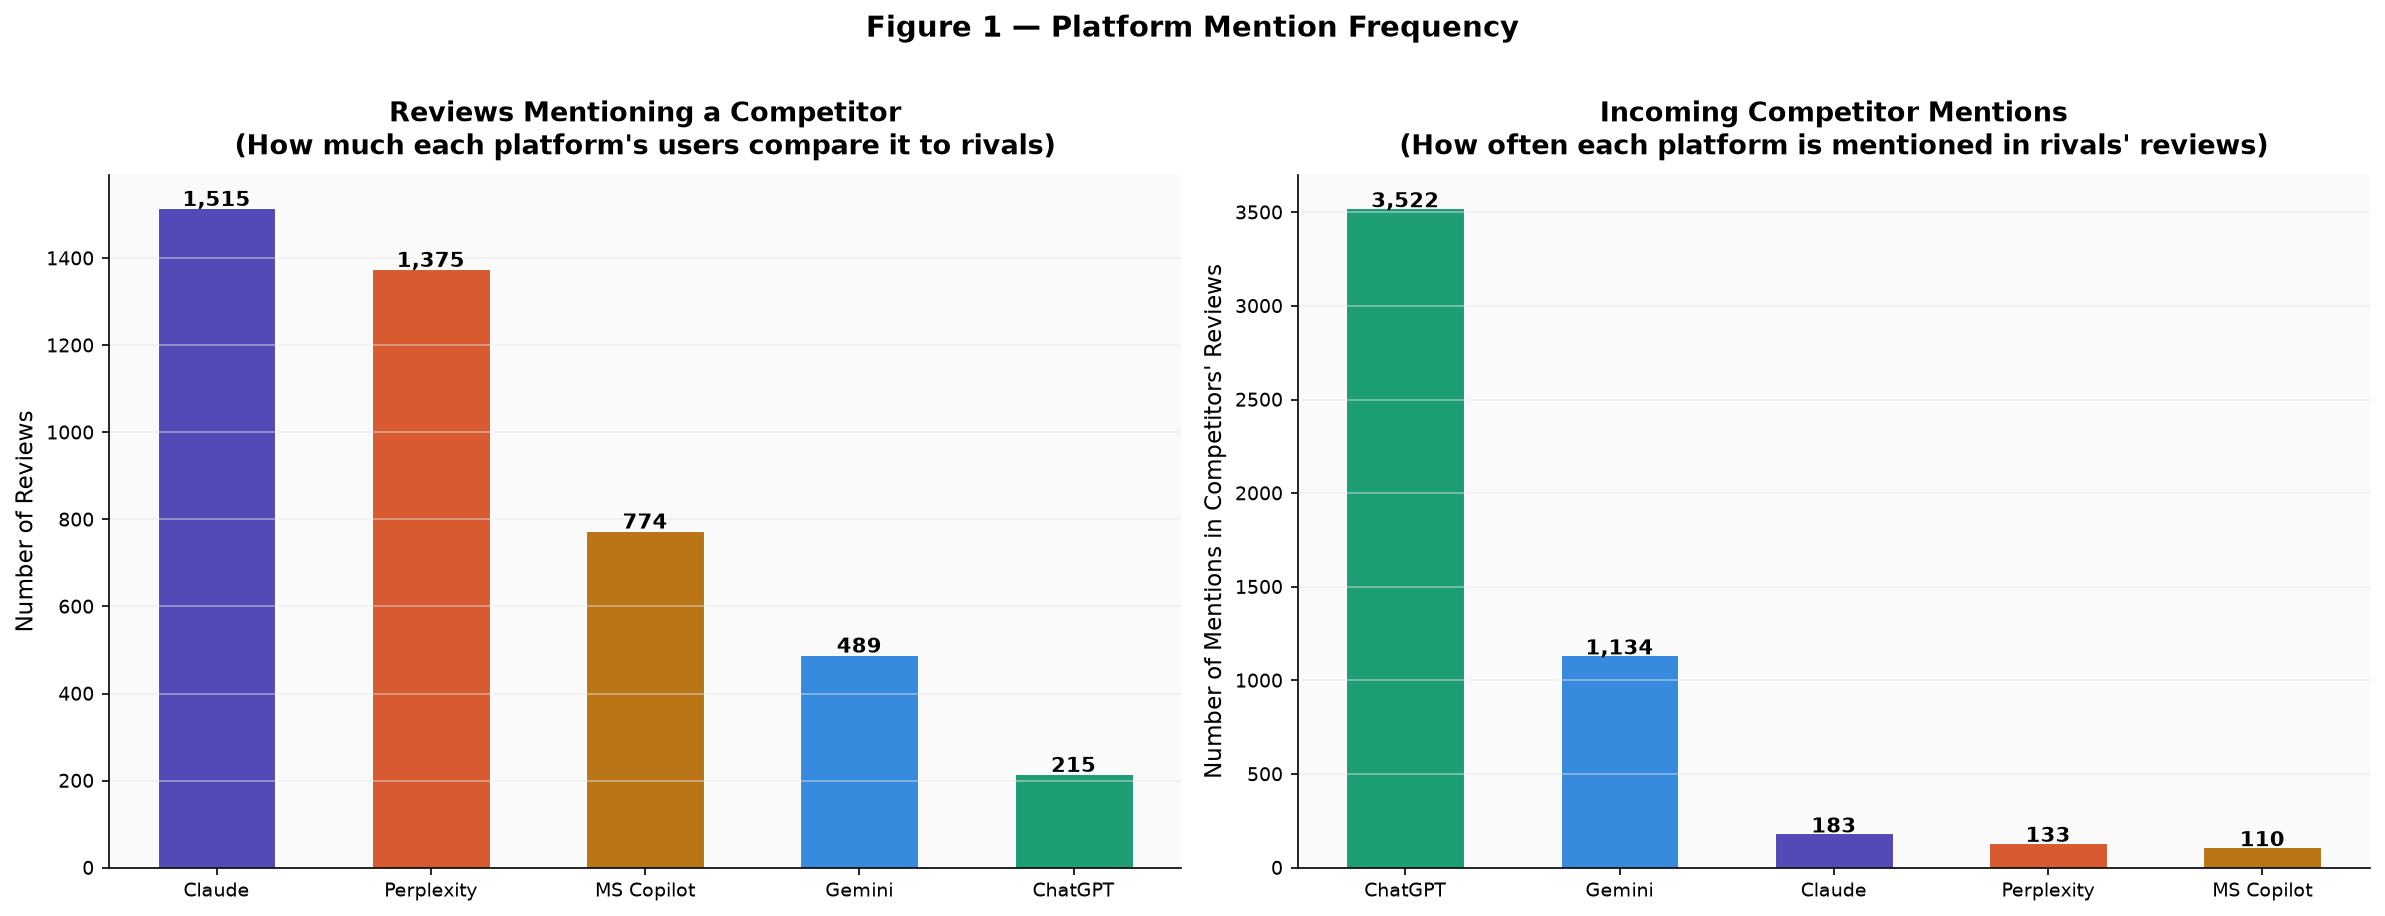

In [16]:
# ── Figure 1: Platform mention frequency ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: how often each platform mentions competitors (outward)
outward = [(APP_LABELS[a], ci_df.loc[APP_LABELS[a], "Comp_Mention_Count"])
           for a in APP_ORDER]
outward.sort(key=lambda x: x[1], reverse=True)
labels1, vals1 = zip(*outward)
colors1 = [APP_COLORS[[a for a in APP_ORDER if APP_LABELS[a]==l][0]] for l in labels1]
bars1 = axes[0].bar(labels1, vals1, color=colors1, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{val:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Reviews Mentioning a Competitor\n(How much each platform's users compare it to rivals)",
                  fontweight="bold", pad=10)
axes[0].grid(axis="y", alpha=0.5)

# Right: how often each platform is MENTIONED (incoming)
inward = [(APP_LABELS[a], incoming_mentions.get(a, 0)) for a in APP_ORDER]
inward.sort(key=lambda x: x[1], reverse=True)
labels2, vals2 = zip(*inward)
colors2 = [APP_COLORS[[a for a in APP_ORDER if APP_LABELS[a]==l][0]] for l in labels2]
bars2 = axes[1].bar(labels2, vals2, color=colors2, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{val:,}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Number of Mentions in Competitors' Reviews")
axes[1].set_title("Incoming Competitor Mentions\n(How often each platform is mentioned in rivals' reviews)",
                  fontweight="bold", pad=10)
axes[1].grid(axis="y", alpha=0.5)

plt.suptitle("Figure 1 — Platform Mention Frequency",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb05_01_platform_mentions.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb05_02_migration_reasons.png


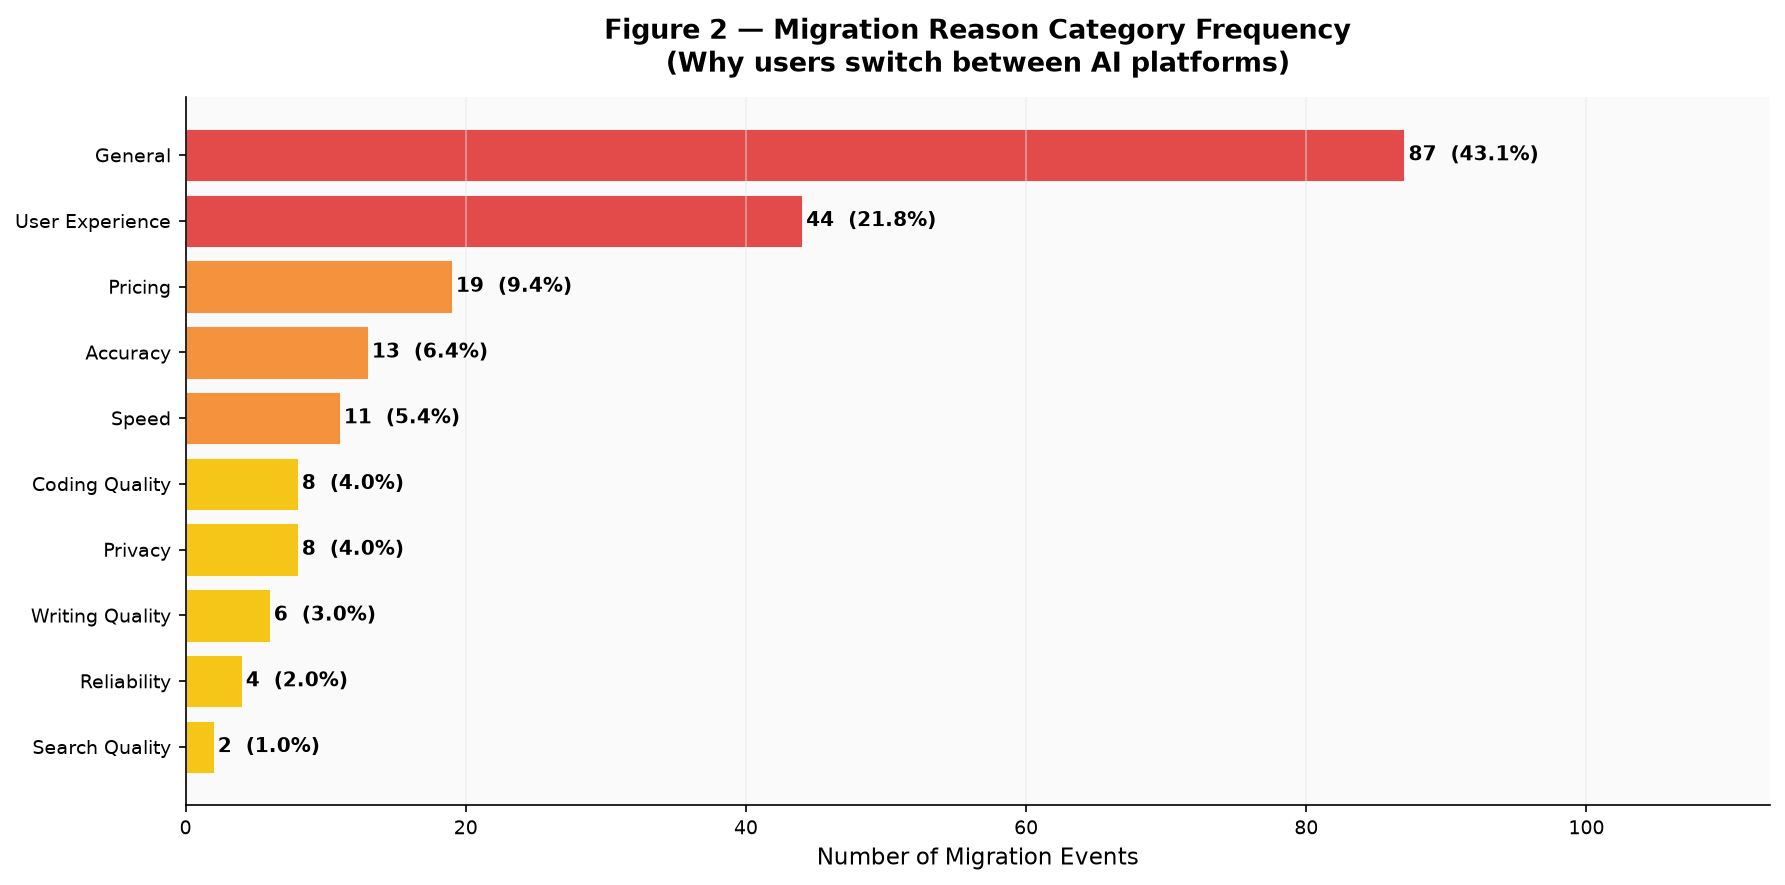

In [17]:
# ── Figure 2: Migration reason frequency ─────────────────────────────────────
if len(reason_counts) > 0:
    _rc_sorted = reason_counts.sort_values("Count", ascending=True)
    _colors2 = ["#E24B4A" if v > 20 else "#F5923E" if v > 10 else "#F5C518"
                for v in _rc_sorted["Count"]]
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(_rc_sorted["Reason Category"], _rc_sorted["Count"],
                   color=_colors2, edgecolor="white", linewidth=0.4)
    for bar, row in zip(bars, _rc_sorted.itertuples()):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height()/2,
                f"{row.Count}  ({row.Percentage:.1f}%)",
                va="center", fontsize=9.5, fontweight="bold")
    ax.set_xlabel("Number of Migration Events")
    ax.set_xlim(0, _rc_sorted["Count"].max() * 1.3)
    ax.set_title("Figure 2 — Migration Reason Category Frequency\n"
                 "(Why users switch between AI platforms)",
                 fontweight="bold", pad=12)
    ax.grid(axis="x", alpha=0.5)
    plt.tight_layout()
    save_fig("fig_nb05_02_migration_reasons.png")
    plt.show()
else:
    print("No migration reason data to plot.")

  📁  Saved → ../outputs/figures/fig_nb05_03_migration_matrix.png


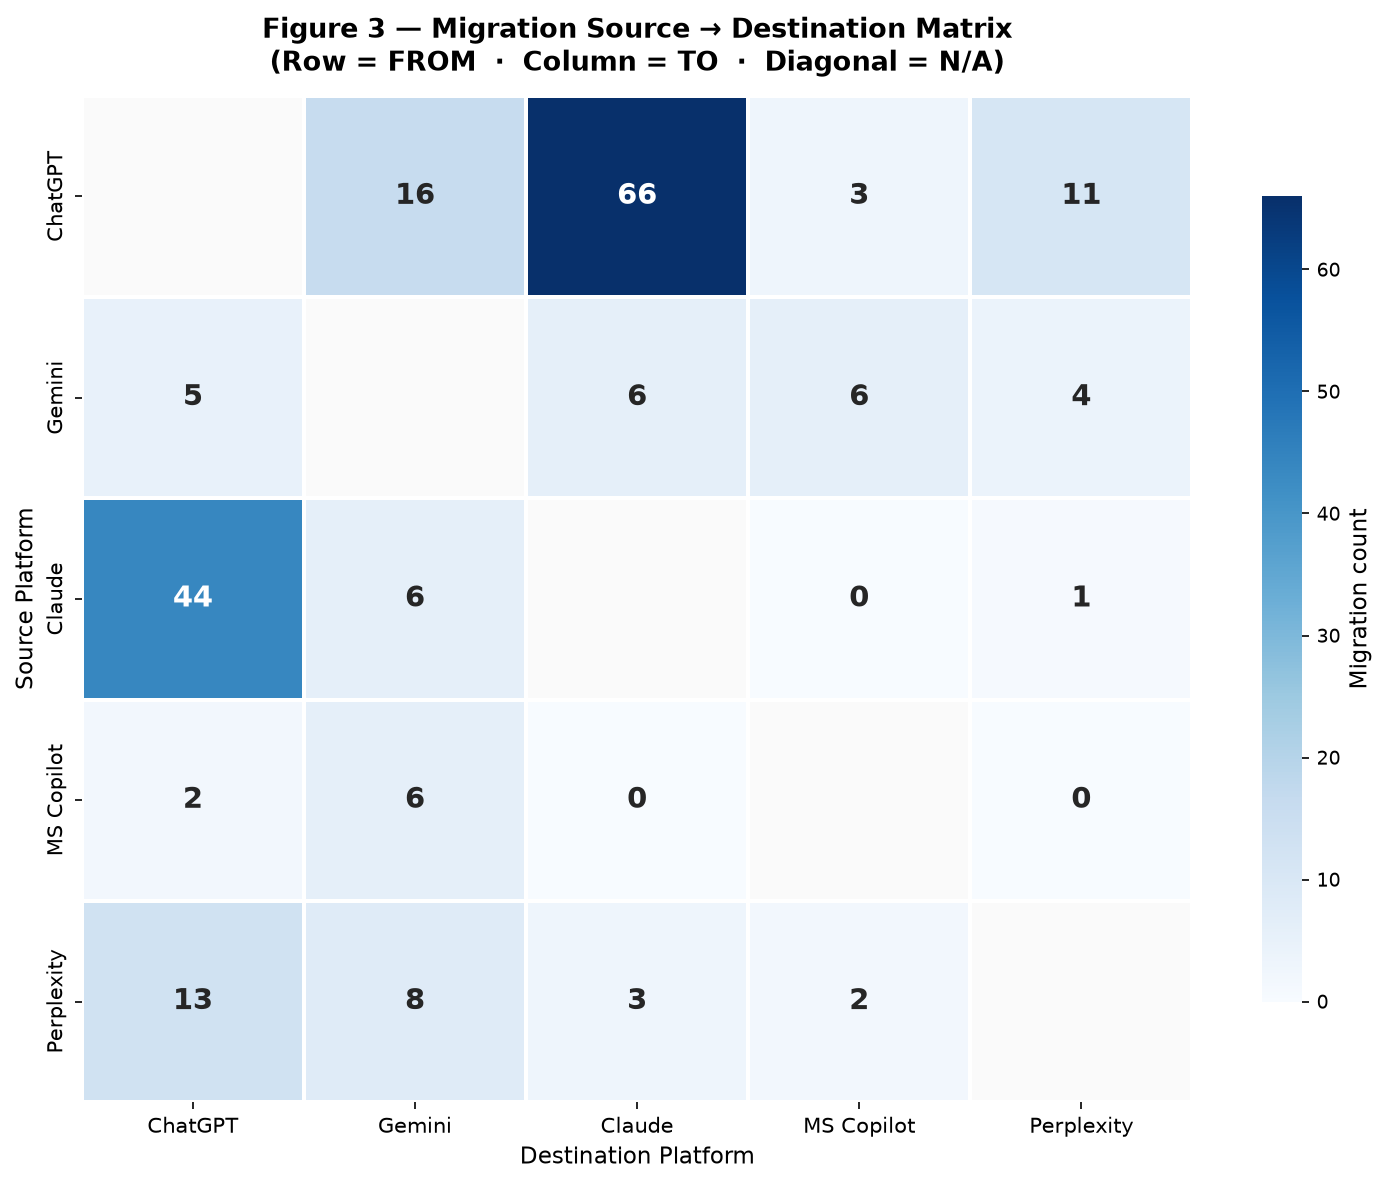

In [18]:
# ── Figure 3: Migration matrix heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
mig_mat_plot = migration_matrix.copy().astype(float)
mig_mat_plot.index   = [APP_LABELS[a] for a in APP_ORDER]
mig_mat_plot.columns = [APP_LABELS[a] for a in APP_ORDER]
# Replace diagonal with NaN so it stands out
for p in mig_mat_plot.index:
    mig_mat_plot.loc[p, p] = np.nan

sns.heatmap(mig_mat_plot, ax=ax,
            annot=True, fmt=".0f",
            annot_kws={"size": 14, "weight": "bold"},
            cmap="Blues",
            linewidths=1, linecolor="white",
            cbar_kws={"shrink": 0.8, "label": "Migration count"},
            mask=mig_mat_plot.isna())
ax.set_xlabel("Destination Platform")
ax.set_ylabel("Source Platform")
ax.set_title("Figure 3 — Migration Source → Destination Matrix\n"
             "(Row = FROM  ·  Column = TO  ·  Diagonal = N/A)",
             fontweight="bold", pad=12)
ax.tick_params(axis="both", labelsize=10)
plt.tight_layout()
save_fig("fig_nb05_03_migration_matrix.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb05_04_network_graph.png


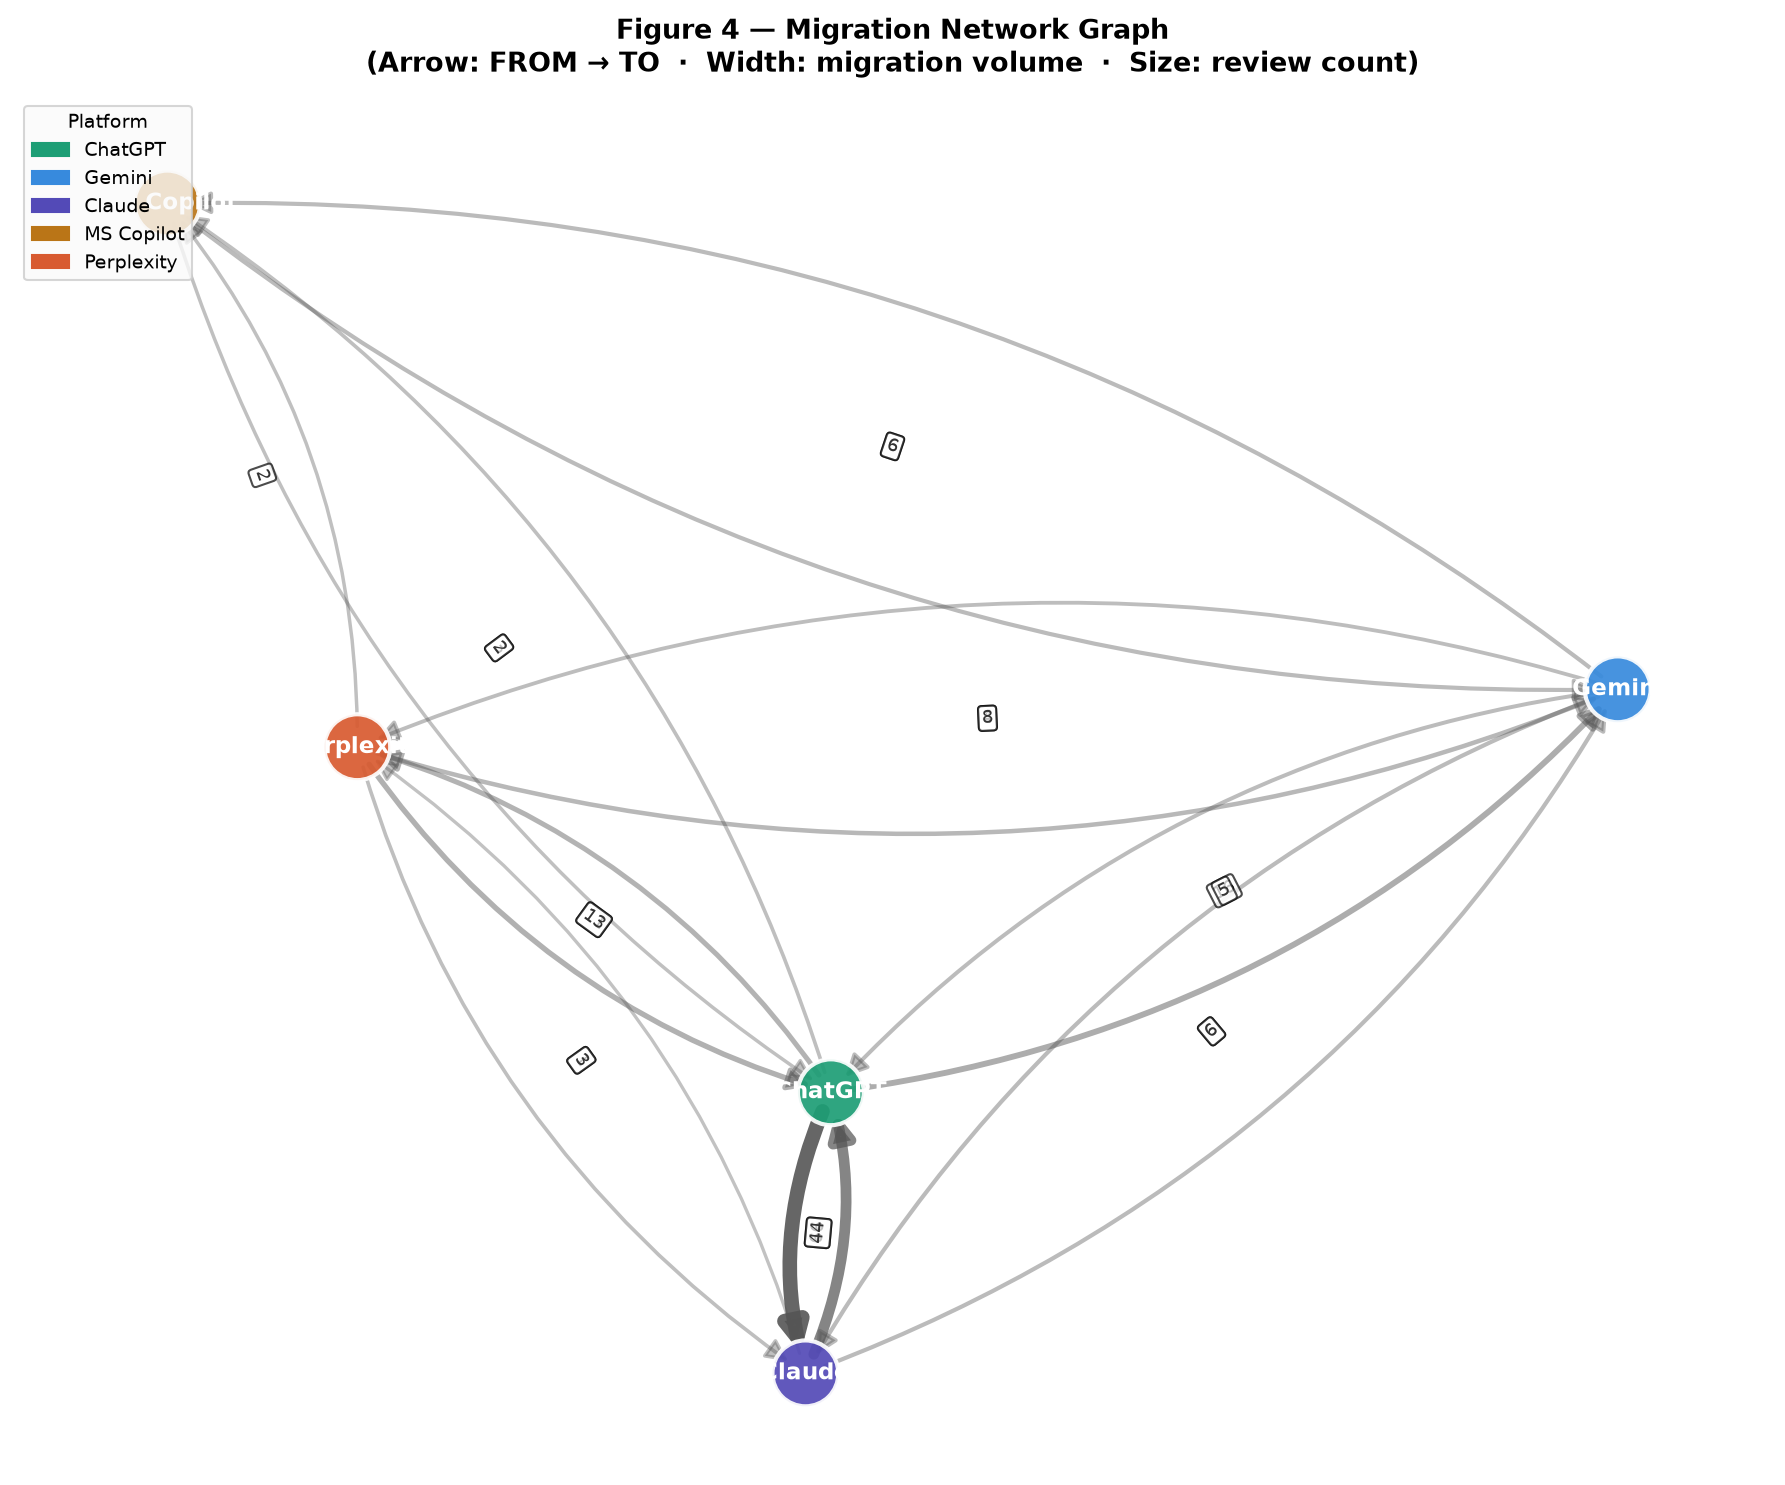

In [19]:
# ── Figure 4: NetworkX migration graph ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor("#F8F8F8")

if G.number_of_edges() > 0:
    pos = nx.spring_layout(G, seed=42, k=2.5)
    node_sizes  = [G.nodes[n]["reviews"] / 25 for n in G.nodes()]
    node_colors = [G.nodes[n]["color"] for n in G.nodes()]
    edge_wts    = [G.edges[e]["weight"] for e in G.edges()]
    max_w       = max(edge_wts) if edge_wts else 1
    edge_widths = [1.5 + 5.5 * (w / max_w) for w in edge_wts]
    edge_alphas = [0.35 + 0.55 * (w / max_w) for w in edge_wts]

    # Draw edges
    for (u, v), w, alpha, lw in zip(G.edges(), edge_wts, edge_alphas, edge_widths):
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            width=lw,
            edge_color=["#555555"],
            alpha=alpha,
            arrows=True,
            arrowsize=22,
            connectionstyle="arc3,rad=0.18",
            ax=ax,
            node_size=node_sizes,
        )

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=[s*2.5 for s in node_sizes],
                           node_color=node_colors, alpha=0.92,
                           edgecolors="white", linewidths=2, ax=ax)

    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=11,
                            font_weight="bold", font_color="white", ax=ax)

    # Add edge weight labels
    edge_labels = {(u,v): d["weight"] for u,v,d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8.5, font_color="#333333",
                                 bbox=dict(boxstyle="round,pad=0.2",
                                           facecolor="white", alpha=0.7), ax=ax)

    # Legend patches
    legend_patches = [
        mpatches.Patch(color=APP_COLORS[a], label=f"{APP_LABELS[a]}")
        for a in APP_ORDER
    ]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9,
              title="Platform", title_fontsize=9)
else:
    ax.text(0.5, 0.5, "No migration edges detected\n(insufficient migration signals in dataset)",
            ha="center", va="center", fontsize=14,
            transform=ax.transAxes, color="#666666")

ax.set_title("Figure 4 — Migration Network Graph\n"
             "(Arrow: FROM → TO  ·  Width: migration volume  ·  Size: review count)",
             fontweight="bold", pad=12, fontsize=13)
ax.axis("off")
plt.tight_layout()
save_fig("fig_nb05_04_network_graph.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb05_05_winner_loser.png


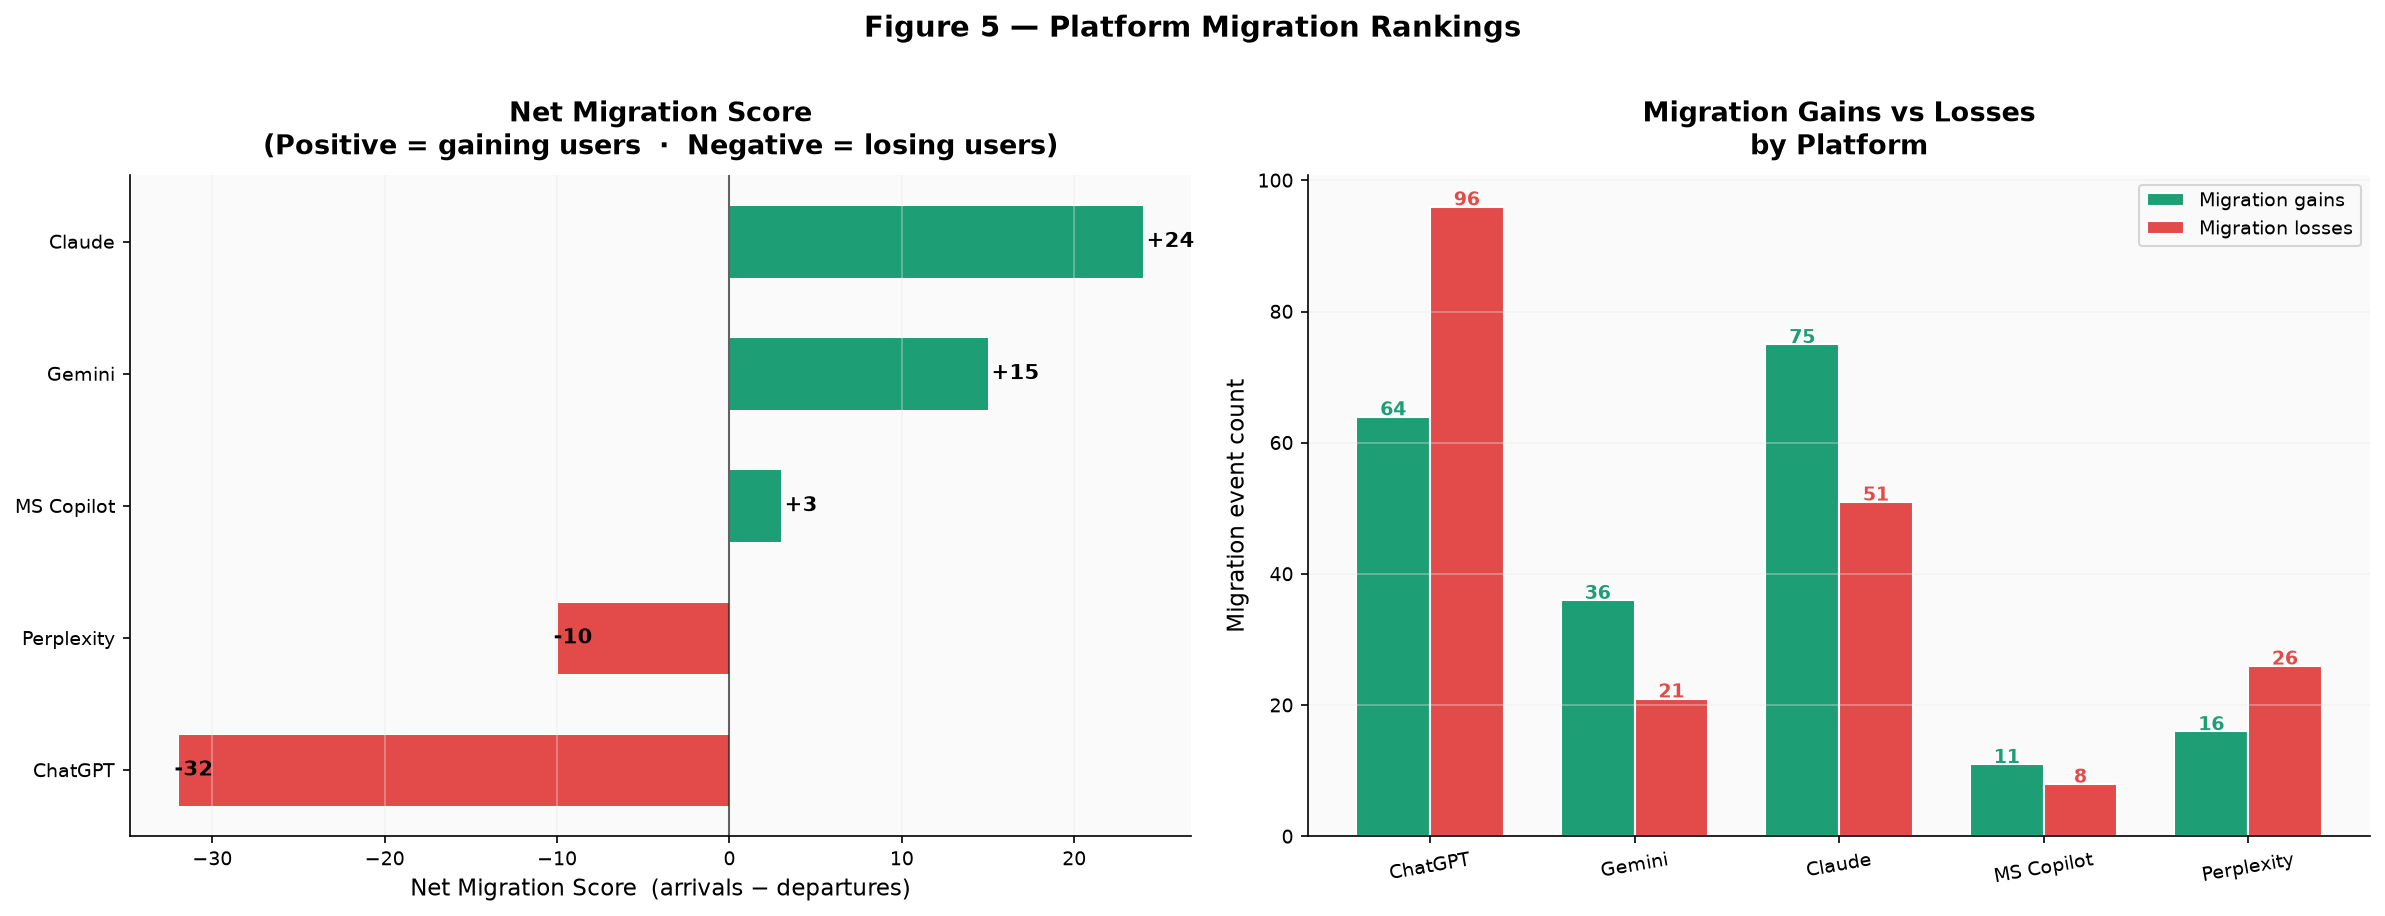

In [20]:
# ── Figure 5: Platform winner / loser ranking ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: net migration score
nets_sorted = sorted(net_scores.items(), key=lambda x: x[1])
labels5     = [x[0] for x in nets_sorted]
values5     = [x[1] for x in nets_sorted]
colors5     = ["#1D9E75" if v >= 0 else "#E24B4A" for v in values5]
bars5 = axes[0].barh(labels5, values5, color=colors5,
                     edgecolor="white", linewidth=0.5, height=0.55)
for bar, val in zip(bars5, values5):
    x_pos = bar.get_width() + (0.2 if val >= 0 else -0.2)
    ha    = "left" if val >= 0 else "right"
    axes[0].text(x_pos, bar.get_y()+bar.get_height()/2,
                 f"{val:+d}", va="center", fontsize=10, fontweight="bold")
axes[0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0].set_xlabel("Net Migration Score  (arrivals − departures)")
axes[0].set_title("Net Migration Score\n(Positive = gaining users  ·  Negative = losing users)",
                  fontweight="bold", pad=10)
axes[0].grid(axis="x", alpha=0.4)

# Right: gains vs losses stacked
x5     = np.arange(len(APP_ORDER))
gains5 = [ci_df.loc[APP_LABELS[a], "Migration_Gains"]  for a in APP_ORDER]
loss5  = [ci_df.loc[APP_LABELS[a], "Migration_Losses"] for a in APP_ORDER]
w5     = 0.36
b_gain = axes[1].bar(x5 - w5/2, gains5, width=w5, color="#1D9E75",
                     label="Migration gains", edgecolor="white")
b_loss = axes[1].bar(x5 + w5/2, loss5, width=w5, color="#E24B4A",
                     label="Migration losses", edgecolor="white")
for bar, val in zip(b_gain, gains5):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f"{val}", ha="center", fontsize=9, color="#1D9E75", fontweight="bold")
for bar, val in zip(b_loss, loss5):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f"{val}", ha="center", fontsize=9, color="#E24B4A", fontweight="bold")
axes[1].set_xticks(x5)
axes[1].set_xticklabels([APP_LABELS[a] for a in APP_ORDER], rotation=10)
axes[1].set_ylabel("Migration event count")
axes[1].set_title("Migration Gains vs Losses\nby Platform",
                  fontweight="bold", pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("Figure 5 — Platform Migration Rankings",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_nb05_05_winner_loser.png")
plt.show()

  📁  Saved → ../outputs/figures/fig_nb05_06_migration_sentiment_heatmap.png


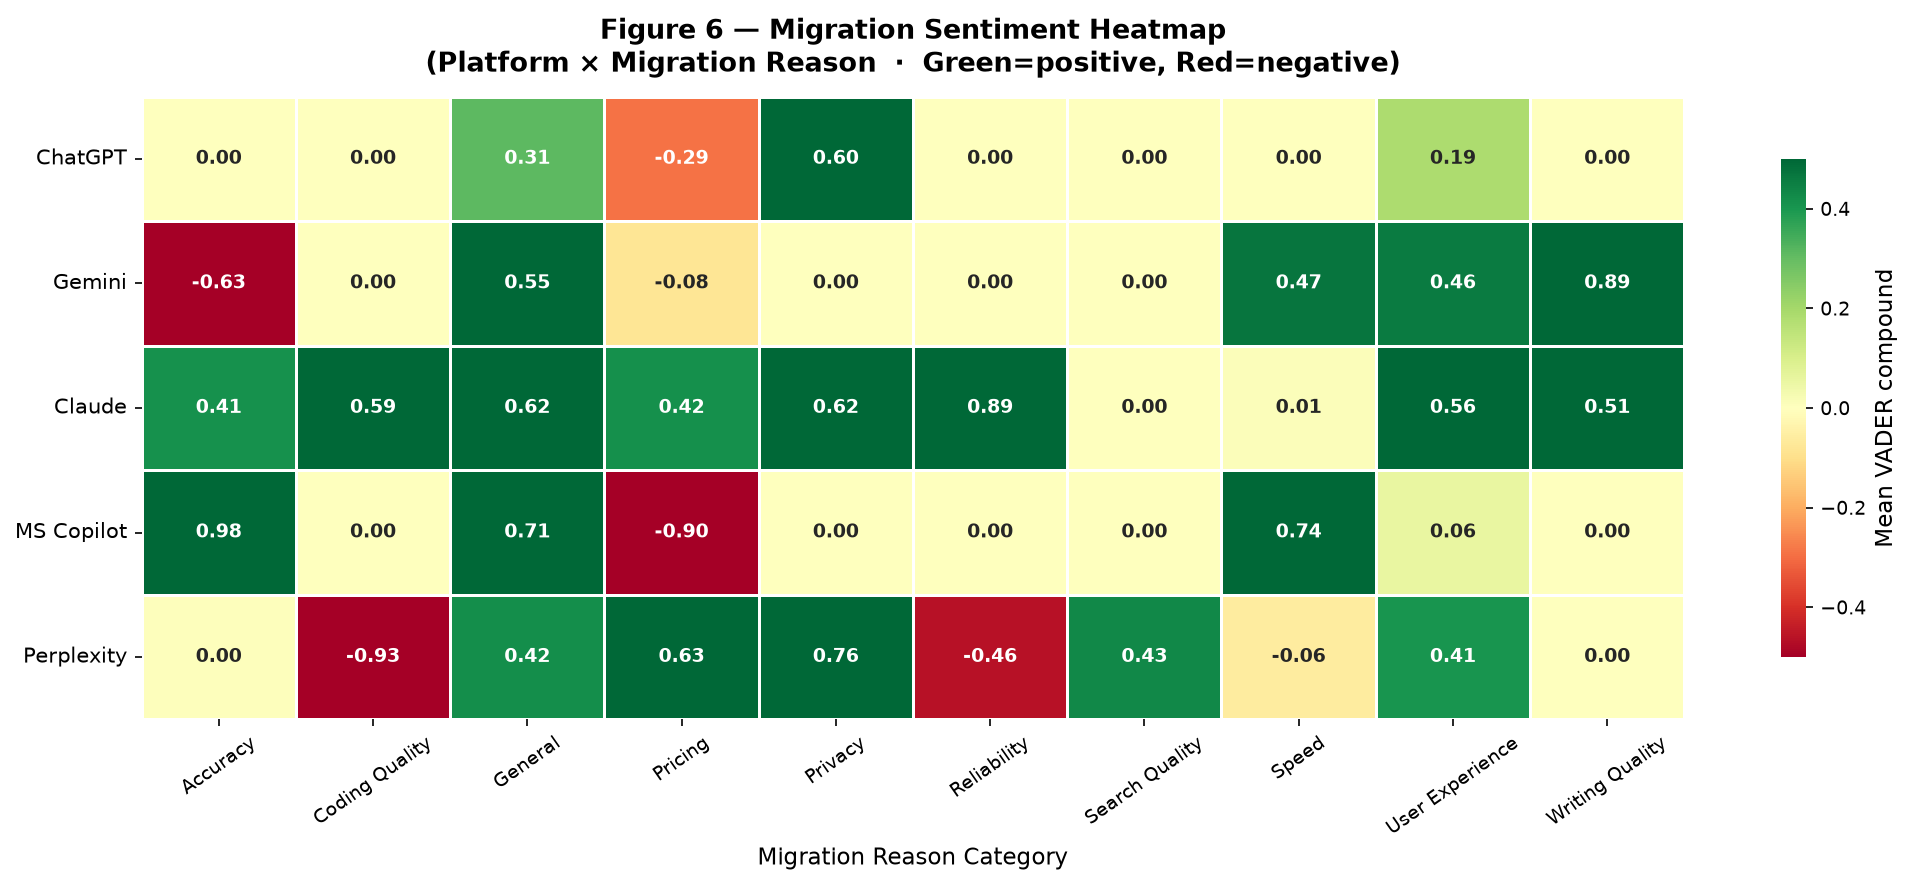

In [21]:
# ── Figure 6: Migration sentiment heatmap ─────────────────────────────────────
if len(mig_reviews) > 0 and "migration_reason_category" in mig_reviews.columns:
    # Platform × reason category mean sentiment
    _mg = mig_reviews.copy()
    _mg["Platform"] = _mg["App"].map(APP_LABELS)
    _mg_valid = _mg[_mg["migration_reason_category"].notna()].copy()

    if len(_mg_valid) > 0:
        heat_data = (_mg_valid.groupby(["Platform", "migration_reason_category"])
                              ["vader_compound"]
                              .mean()
                              .unstack(fill_value=0))
        # Reorder rows
        heat_data = heat_data.reindex(
            [APP_LABELS[a] for a in APP_ORDER if APP_LABELS[a] in heat_data.index]
        )
        fig, ax = plt.subplots(figsize=(14, 6))
        sns.heatmap(heat_data, ax=ax,
                    annot=True, fmt=".2f",
                    annot_kws={"size": 9, "weight": "bold"},
                    cmap="RdYlGn", vmin=-0.5, vmax=0.5, center=0,
                    linewidths=0.5, linecolor="white",
                    cbar_kws={"shrink": 0.8, "label": "Mean VADER compound"})
        ax.set_title("Figure 6 — Migration Sentiment Heatmap\n"
                     "(Platform × Migration Reason  ·  Green=positive, Red=negative)",
                     fontweight="bold", pad=12)
        ax.set_xlabel("Migration Reason Category")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=35, labelsize=9)
        ax.tick_params(axis="y", labelsize=10, rotation=0)
        plt.tight_layout()
        save_fig("fig_nb05_06_migration_sentiment_heatmap.png")
        plt.show()
    else:
        print("Insufficient data for migration sentiment heatmap.")
else:
    print("No migration reason data for heatmap.")

  📁  Saved → ../outputs/figures/fig_nb05_07_competitive_dashboard.png


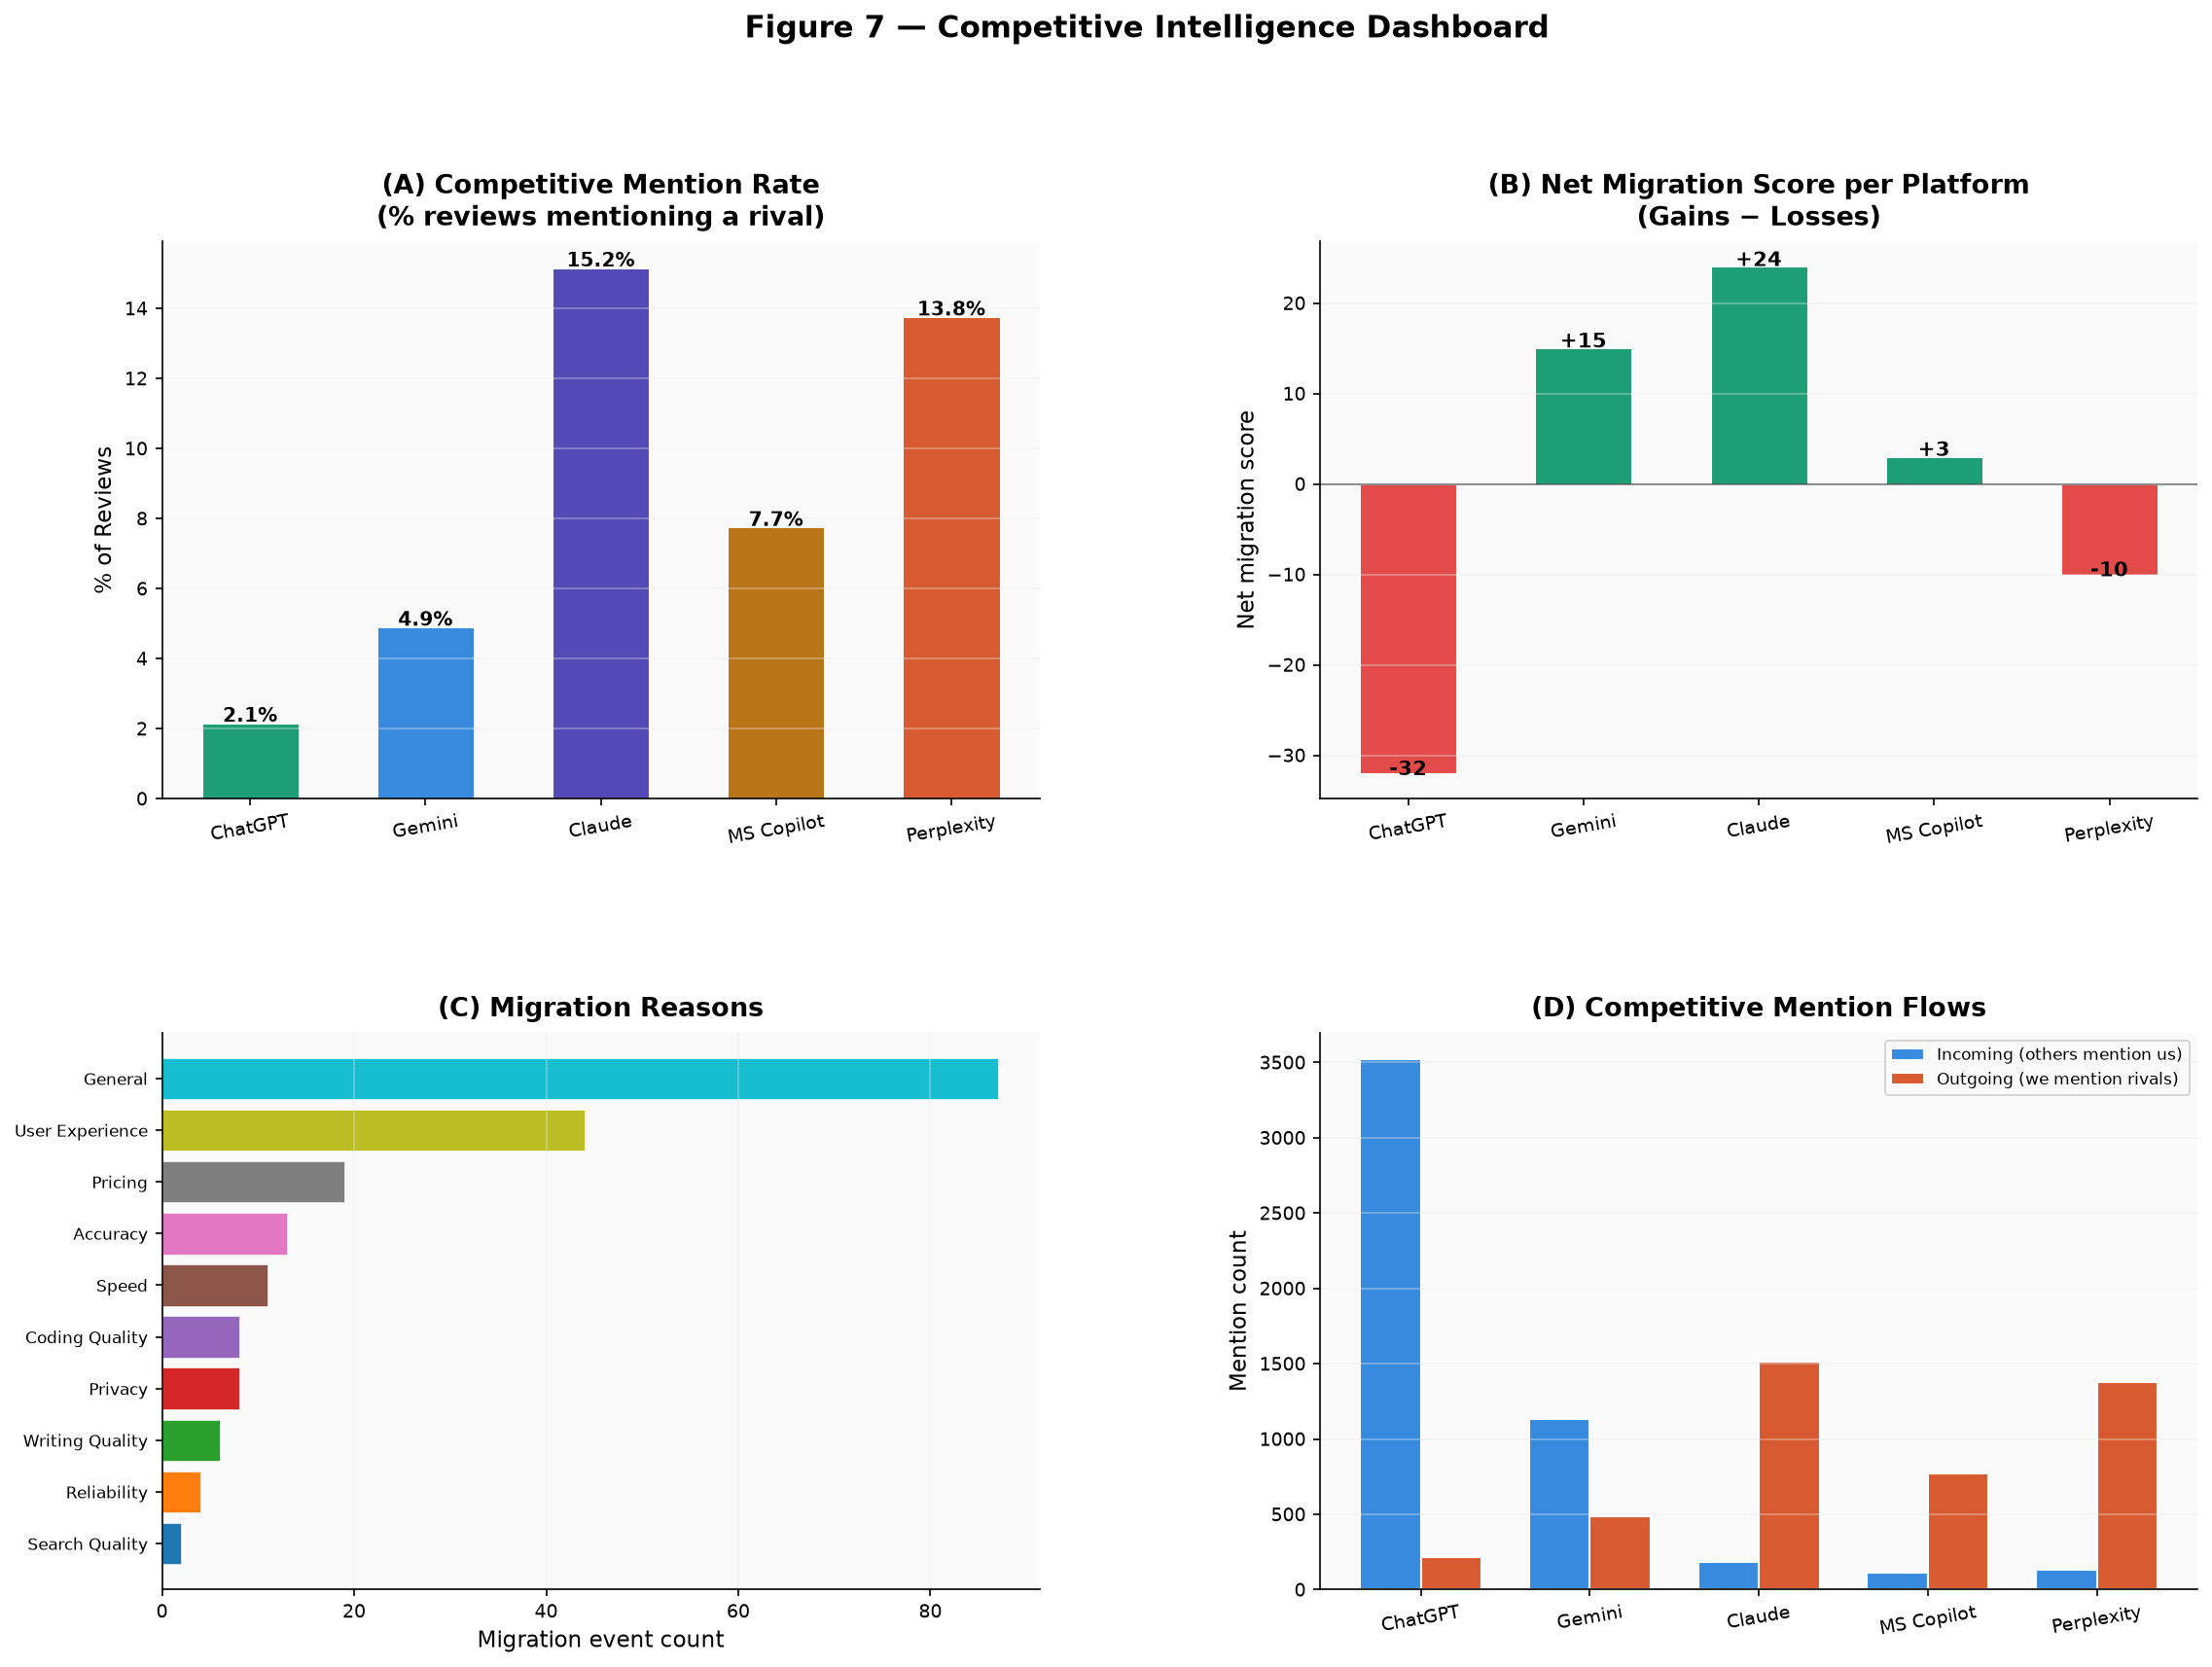

In [22]:
# ── Figure 7: Competitive intelligence dashboard (4-panel) ────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

_app_d = [APP_LABELS[a] for a in APP_ORDER]

# Panel A: Competitive mention rate (% of reviews that mention a competitor)
_cr = [ci_df.loc[APP_LABELS[a], "Comp_Mention_Rate_%"] for a in APP_ORDER]
bars_a = ax1.bar(_app_d, _cr, color=PALETTE, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars_a, _cr):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f"{val:.1f}%", ha="center", fontsize=9.5, fontweight="bold")
ax1.set_ylabel("% of Reviews")
ax1.set_title("(A) Competitive Mention Rate\n(% reviews mentioning a rival)",
              fontweight="bold", pad=8)
ax1.grid(axis="y", alpha=0.4)
ax1.tick_params(axis="x", rotation=10)

# Panel B: Net migration score
nets_b   = [net_scores[APP_LABELS[a]] for a in APP_ORDER]
colors_b = ["#1D9E75" if v >= 0 else "#E24B4A" for v in nets_b]
bars_b   = ax2.bar(_app_d, nets_b, color=colors_b, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars_b, nets_b):
    ypos = bar.get_height() + 0.1 if val >= 0 else bar.get_height() - 0.2
    ax2.text(bar.get_x()+bar.get_width()/2, ypos,
             f"{val:+d}", ha="center", fontsize=10, fontweight="bold")
ax2.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax2.set_ylabel("Net migration score")
ax2.set_title("(B) Net Migration Score per Platform\n(Gains − Losses)",
              fontweight="bold", pad=8)
ax2.grid(axis="y", alpha=0.4)
ax2.tick_params(axis="x", rotation=10)

# Panel C: Top migration reasons (horizontal bar)
if len(reason_counts) > 0:
    _rcs = reason_counts.sort_values("Count", ascending=True)
    _rc_colors = plt.cm.tab10.colors[:len(_rcs)]
    ax3.barh(_rcs["Reason Category"], _rcs["Count"],
             color=_rc_colors, edgecolor="white", linewidth=0.3)
    ax3.set_xlabel("Migration event count")
    ax3.set_title("(C) Migration Reasons",
                  fontweight="bold", pad=8)
    ax3.grid(axis="x", alpha=0.4)
    ax3.tick_params(axis="y", labelsize=8)

# Panel D: Incoming vs outgoing mentions (grouped bar)
_inc = [incoming_mentions.get(a, 0) for a in APP_ORDER]
_out = [ci_df.loc[APP_LABELS[a], "Comp_Mention_Count"] for a in APP_ORDER]
x4   = np.arange(len(APP_ORDER))
w4   = 0.36
ax4.bar(x4 - w4/2, _inc, width=w4, color="#378ADD", label="Incoming (others mention us)", edgecolor="white")
ax4.bar(x4 + w4/2, _out, width=w4, color="#D85A30", label="Outgoing (we mention rivals)",  edgecolor="white")
ax4.set_xticks(x4)
ax4.set_xticklabels(_app_d, rotation=10)
ax4.set_ylabel("Mention count")
ax4.set_title("(D) Competitive Mention Flows",
              fontweight="bold", pad=8)
ax4.legend(fontsize=8)
ax4.grid(axis="y", alpha=0.4)

plt.suptitle("Figure 7 — Competitive Intelligence Dashboard",
             fontsize=15, fontweight="bold", y=1.01)
save_fig("fig_nb05_07_competitive_dashboard.png")
plt.show()

---
## 💾 Section 10 — Export Results

In [23]:
print("Saving outputs...")
_t0 = time.time()

# ── Main enriched dataset ──────────────────────────────────────────────────────
df.to_parquet(OUT_PARQ, index=False, engine="pyarrow")
_ps = os.path.getsize(OUT_PARQ) / 1e6
print(f"  ✅  reviews_migration.parquet  ({_ps:.1f} MB)")

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
_cs = os.path.getsize(OUT_CSV) / 1e6
print(f"  ✅  reviews_migration.csv      ({_cs:.1f} MB)")

# ── Migration summary CSV ──────────────────────────────────────────────────────
mig_summary_cols = [
    "App", "Star_Rating", "vader_compound", "vader_label",
    "migration_source", "migration_destination",
    "migration_phrase", "migration_reason_category",
    "migration_reason_text", "lda_topic_label",
]
mig_export = df[df["migration_flag"] == True][
    [c for c in mig_summary_cols if c in df.columns]
].copy()
mig_export["migration_source"]      = mig_export["migration_source"].map(
    lambda x: APP_LABELS.get(x, x) if x else x)
mig_export["migration_destination"] = mig_export["migration_destination"].map(
    lambda x: APP_LABELS.get(x, x) if x else x)
mig_export["App"] = mig_export["App"].map(APP_LABELS)
mig_export.to_csv(OUT_MIGSUM, index=False)
print(f"  ✅  migration_summary.csv      ({len(mig_export):,} rows)")

# ── Competitive intelligence CSV ───────────────────────────────────────────────
ci_df.to_csv(OUT_CI)
print(f"  ✅  platform_competitive_intelligence.csv  ({len(ci_df)} platforms)")

# ── Round-trip verify ─────────────────────────────────────────────────────────
_chk = pd.read_parquet(OUT_PARQ)
assert _chk.shape == df.shape, "Parquet round-trip shape mismatch!"
print(f"\n✅  Round-trip verified: {_chk.shape[0]:,} rows × {_chk.shape[1]} columns")
print(f"    Total save time: {time.time()-_t0:.1f}s")
print()
print("New columns added by NB05:")
new_cols = ["mentioned_platforms","mention_count","mentions_competitor",
            "migration_flag","migration_source","migration_destination",
            "migration_phrase","migration_reason_text","migration_reason_category"]
for c in new_cols:
    nn = df[c].notna().sum() if c in df.columns else 0
    print(f"  {c:<32}  non-null={nn:,}")

Saving outputs...
  ✅  reviews_migration.parquet  (14.4 MB)
  ✅  reviews_migration.csv      (33.0 MB)
  ✅  migration_summary.csv      (202 rows)
  ✅  platform_competitive_intelligence.csv  (5 platforms)

✅  Round-trip verified: 50,000 rows × 58 columns
    Total save time: 2.1s

New columns added by NB05:
  mentioned_platforms               non-null=50,000
  mention_count                     non-null=50,000
  mentions_competitor               non-null=50,000
  migration_flag                    non-null=50,000
  migration_source                  non-null=202
  migration_destination             non-null=202
  migration_phrase                  non-null=202
  migration_reason_text             non-null=202
  migration_reason_category         non-null=202


---
## 📋 Section 11 — Executive Summary & Competitive Intelligence Report

In [24]:
print("=" * 70)
print("  COMPETITIVE INTELLIGENCE REPORT — SENTIMENTCOMPASS NB05")
print("=" * 70)

# ── Overview stats ────────────────────────────────────────────────────────────
n_mentions  = df["mentions_competitor"].sum()
n_migration = df["migration_flag"].sum()
print()
print("── OVERVIEW ─────────────────────────────────────────────────────────────")
print(f"  Total reviews analysed          : {len(df):,}")
print(f"  Reviews mentioning a competitor : {n_mentions:,}  ({n_mentions/len(df)*100:.1f}%)")
print(f"  Migration signals detected      : {n_migration:,}  ({n_migration/len(df)*100:.2f}%)")
print(f"  Migration events as % of mentions: {n_migration/max(n_mentions,1)*100:.1f}%")

# ── Most mentioned competitor ─────────────────────────────────────────────────
all_comp_mentions = []
for m in df["mentioned_platforms"].dropna():
    if m:
        all_comp_mentions.extend(m.split("|"))
if all_comp_mentions:
    most_mentioned_app = pd.Series(all_comp_mentions).value_counts().idxmax()
    most_mentioned_cnt = pd.Series(all_comp_mentions).value_counts().max()
    print()
    print("── MOST MENTIONED COMPETITOR ────────────────────────────────────────────")
    print(f"  {APP_LABELS[most_mentioned_app]} is mentioned {most_mentioned_cnt:,} times "
          f"across all competitor reviews")
    print(f"  → This platform is the most prominent competitor in users' minds")

# ── Migration winner / loser ──────────────────────────────────────────────────
print()
print("── MIGRATION WINNERS & LOSERS ───────────────────────────────────────────")
for rank, (platform, net) in enumerate(net_sorted, 1):
    marker = "🏆" if rank == 1 else ("📉" if rank == len(net_sorted) else "  ")
    gains_v = ci_df.loc[platform, "Migration_Gains"]
    loss_v  = ci_df.loc[platform, "Migration_Losses"]
    print(f"  {marker} #{rank}  {platform:<14}  "
          f"net={net:>+4}  (gains={gains_v}  losses={loss_v})")

# ── Strongest migration path ──────────────────────────────────────────────────
if mig_df is not None and len(mig_df) > 0:
    mig_flows_top = (mig_df.dropna(subset=["migration_source","migration_destination"])
                    .groupby(["migration_source","migration_destination"])
                    .size()
                    .sort_values(ascending=False))
    if len(mig_flows_top) > 0:
        top_src, top_dst = mig_flows_top.index[0]
        top_vol          = int(mig_flows_top.iloc[0])
        print()
        print("── STRONGEST MIGRATION PATH ─────────────────────────────────────────────")
        print(f"  {APP_LABELS.get(top_src, top_src)} → {APP_LABELS.get(top_dst, top_dst)}")
        print(f"  Volume: {top_vol} migration events")
        print(f"  → This is the most active competitive switching path in the dataset")

# ── Most common migration reason ─────────────────────────────────────────────
if len(reason_counts) > 0:
    top_reas     = reason_counts.iloc[0]["Reason Category"]
    top_reas_pct = reason_counts.iloc[0]["Percentage"]
    print()
    print("── TOP MIGRATION REASON ─────────────────────────────────────────────────")
    print(f"  {top_reas} ({top_reas_pct:.1f}% of migration events)")
    print(f"  → Users most commonly switch due to {top_reas.lower()} concerns")

# ── Competitive insights ──────────────────────────────────────────────────────
print()
print("── KEY COMPETITIVE INSIGHTS ─────────────────────────────────────────────")
insights = [
    f"Platform with highest competitive mention rate: "
    f"{ci_df['Comp_Mention_Rate_%'].idxmax()} "
    f"({ci_df['Comp_Mention_Rate_%'].max():.1f}%)",

    f"Platform most mentioned in rivals' reviews: "
    f"{APP_LABELS.get(most_mentioned_app, 'N/A')} "
    f"({most_mentioned_cnt:,} mentions)",

    f"Net migration winner: {net_sorted[0][0]} (net={net_sorted[0][1]:+d})",
    f"Net migration loser : {net_sorted[-1][0]} (net={net_sorted[-1][1]:+d})",
]
for insight in insights:
    print(f"  • {insight}")

# ── Output files ──────────────────────────────────────────────────────────────
print()
print("── OUTPUT FILES ─────────────────────────────────────────────────────────")
for path in [OUT_PARQ, OUT_CSV, OUT_MIGSUM, OUT_CI]:
    sz = os.path.getsize(path) / 1e6 if os.path.exists(path) else 0
    ok = "✅" if os.path.exists(path) else "❌"
    print(f"  {ok}  {os.path.basename(path):<45}  ({sz:.1f} MB)")

print()
print("=" * 70)
print("  ▶  Next: build the Streamlit Dashboard (dashboard/app.py)")
print("=" * 70)

  COMPETITIVE INTELLIGENCE REPORT — SENTIMENTCOMPASS NB05

── OVERVIEW ─────────────────────────────────────────────────────────────
  Total reviews analysed          : 50,000
  Reviews mentioning a competitor : 4,368  (8.7%)
  Migration signals detected      : 202  (0.40%)
  Migration events as % of mentions: 4.6%

── MOST MENTIONED COMPETITOR ────────────────────────────────────────────
  ChatGPT is mentioned 3,522 times across all competitor reviews
  → This platform is the most prominent competitor in users' minds

── MIGRATION WINNERS & LOSERS ───────────────────────────────────────────
  🏆 #1  Claude          net= +24  (gains=75  losses=51)
     #2  Gemini          net= +15  (gains=36  losses=21)
     #3  MS Copilot      net=  +3  (gains=11  losses=8)
     #4  Perplexity      net= -10  (gains=16  losses=26)
  📉 #5  ChatGPT         net= -32  (gains=64  losses=96)

── STRONGEST MIGRATION PATH ─────────────────────────────────────────────
  ChatGPT → Claude
  Volume: 66 migration ev

---
## 📌 Handoff to Streamlit Dashboard

| Column / File | Produced here | Dashboard use |
|---------------|-------------|---------------|
| `mentioned_platforms` | ✅ | Competitor mention filter |
| `mentions_competitor` | ✅ | Competitive review flag |
| `migration_flag` | ✅ | Migration review segmentation |
| `migration_source` / `migration_destination` | ✅ | Network graph edge data |
| `migration_reason_category` | ✅ | Migration reason bar chart |
| `migration_summary.csv` | ✅ | Downloadable migration report |
| `platform_competitive_intelligence.csv` | ✅ | Scorecard table page |

**▶ All five notebooks complete. Proceed to `dashboard/app.py`.**